This project builds a **cross-language, comparable dataset** of Wikipedia content about countries.

**Pipeline logic:**
1. Start from a list of countries (with HDI group info).
2. For each country and each page type (`main`, `economy`, `politics`), find the **English Wikipedia page**.
3. Extract the page’s **Wikidata QID** (unique entity identifier).
4. Use that QID to fetch the **matching pages in other languages** via Wikidata sitelinks.
5. Save a “targets” table: one row per `(country, page_type, language)` pointing to the exact Wikipedia title/page.

This targets table is later used to extract sections and label framing with an LLM.


In [1]:
from __future__ import annotations

import json
import re
import time
from typing import Any

import os
import requests
import pandas as pd
from tqdm import tqdm

# =========================
# 0) GLOBAL RUN CONFIG
# =========================

# Page categories you want to compare across countries
# - main: country overview
# - economy: economy-focused article
# - politics: governance/politics-focused article
PAGE_TYPES = ["main", "economy", "politics"]

# Languages to include in the cross-language comparison
# IMPORTANT: We use Wikidata sitelinks to align the *same entity* across languages.
LANGS = ["en", "ru", "fr", "es"]

# Input countries table (must exist)
# Expected columns: country, hdi_group (optionally hdi_rank, hdi_value)
COUNTRIES_CSV = "countries.csv"

# Output folder for all intermediate/final tables produced by this stage
OUT_DIR = "data"
os.makedirs(OUT_DIR, exist_ok=True)

# Targets output:
# - targets.csv: resolved pages that exist (aligned by QID)
# - targets_missing.csv: pages we failed to resolve (for transparency + reruns)
TARGETS_CSV = f"{OUT_DIR}/targets.csv"
MISSING_TARGETS_CSV = f"{OUT_DIR}/targets_missing.csv"

# =========================
# 1) TITLE CONSTRUCTION
# =========================

# Deterministic EN title patterns + minimal overrides for known exceptions.
# Why: EN titles are our "anchor" to find the QID reliably.
TITLE_OVERRIDES = {
    ("United States", "economy"): "Economy of the United States",
    ("United States", "politics"): "Politics of the United States",
}

def en_title(country: str, page_type: str) -> str:
    """
    Create the *English Wikipedia* title for a (country, page_type).

    Why this exists:
    - We use EN as the anchor language because title patterns are consistent.
    - Once we resolve the EN page, we extract the Wikidata QID and
      get all other languages via sitelinks (avoids brittle title matching).
    """
    # Handle known exceptions first (hard overrides)
    if (country, page_type) in TITLE_OVERRIDES:
        return TITLE_OVERRIDES[(country, page_type)]

    # Default title patterns (works for most countries)
    if page_type == "main":
        return country
    if page_type == "economy":
        return f"Economy of {country}"
    if page_type == "politics":
        return f"Politics of {country}"

    # If we ever add new page types, fail loudly so we don’t silently mislabel data
    raise ValueError(f"Unknown page_type: {page_type}")


### Robust API fetching

Wikipedia and Wikidata APIs occasionally rate-limit or return transient server errors.  
This helper wraps `requests.get()` with:

- a **real User-Agent** (required by Wikimedia etiquette and to avoid blocks),
- **retry + backoff** for transient HTTP errors (e.g., 429, 5xx),
- basic protection against **non-JSON** responses (e.g., proxy HTML),
- a single JSON return type so downstream code stays clean.


In [ ]:
import random
import time
import requests

# =========================
# 2) HTTP / API UTILITIES
# =========================

# Wikimedia expects a descriptive User-Agent with a real contact.
DEFAULT_HEADERS = {
    "User-Agent": "DataAndSocietySeminar/1.0 (contact: elina@example.com)",
    "Accept": "application/json",
}

# HTTP codes that often resolve on retry
TRANSIENT_STATUS = {429, 500, 502, 503, 504}

def get_json(
    url: str,
    params: dict,
    session: requests.Session,
    *,
    retries: int = 6,
    timeout: int = 30
) -> dict:
    """
    GET an API endpoint and return parsed JSON with retries/backoff.

    Why this exists:
    - Wikipedia/Wikidata APIs can rate-limit (429) or intermittently fail (5xx).
    - Retrying with exponential backoff increases robustness for long batch runs.
    - We also guard against "HTML instead of JSON" responses (proxy/captive portal),
      which otherwise cause confusing downstream failures.
    """
    last_exc = None

    for attempt in range(1, retries + 1):
        try:
            r = session.get(url, params=params, headers=DEFAULT_HEADERS, timeout=timeout)

            # 403 is usually a policy/UA issue; retrying wastes time.
            if r.status_code == 403:
                raise requests.HTTPError(
                    "403 Forbidden (likely User-Agent, network policy, or blocked endpoint). "
                    f"UA={DEFAULT_HEADERS.get('User-Agent')} URL={r.url}"
                )

            # Retry transient issues with exponential backoff (+ jitter)
            if r.status_code in TRANSIENT_STATUS:
                retry_after = r.headers.get("Retry-After")

                # If Retry-After is present and numeric, respect it; otherwise exponential backoff.
                if retry_after and retry_after.isdigit():
                    base = float(retry_after)
                else:
                    base = 1.5 ** attempt

                time.sleep(min(base + random.random(), 15))
                continue

            # Raise for non-2xx
            r.raise_for_status()

            # Catch non-JSON responses (common if a proxy injects HTML)
            ctype = r.headers.get("Content-Type", "")
            if "application/json" not in ctype and not r.text.lstrip().startswith("{"):
                raise RuntimeError(
                    f"Non-JSON response (Content-Type={ctype}) head={r.text[:120]!r}"
                )

            return r.json()

        except Exception as e:
            last_exc = e
            if attempt == retries:
                break
            time.sleep(min((1.5 ** attempt) + random.random(), 8))

    raise RuntimeError(
        f"GET failed after {retries} retries\n"
        f"URL: {url}\n"
        f"params: {params}\n"
        f"last error: {repr(last_exc)}"
    )


### Resolve a Wikipedia title to a canonical page (+ QID)

Given a `(language, title)`, this function queries the Wikipedia API to:

- follow redirects to the canonical page,
- reject missing and disambiguation pages,
- return stable identifiers (`pageid`, canonical `title`, `fullurl`),
- extract the Wikidata **QID** (`wikibase_item`) when available.

The QID is the key that later lets us align the *same entity* across languages via Wikidata sitelinks.


In [3]:
from typing import Optional
import requests

def resolve_wikipedia_title(lang: str, title: str, session: requests.Session) -> Optional[dict]:
    """
    Resolve a language-specific Wikipedia title to a canonical page record.

    Why this exists:
    - Wikipedia titles can redirect; we want the canonical target.
    - We need a stable identifier (pageid) and ideally the Wikidata QID.
    - We avoid disambiguation pages because they break entity alignment.
    """
    api = f"https://{lang}.wikipedia.org/w/api.php"

    data = get_json(
        api,
        params={
            "action": "query",
            "format": "json",
            "formatversion": "2",
            "titles": title,
            "redirects": "1",          # follow redirects automatically
            "prop": "info|pageprops",  # pageprops includes wikibase_item (QID)
            "inprop": "url",           # include fullurl for debugging / transparency
        },
        session=session,
    )

    pages = (data.get("query", {}) or {}).get("pages", []) or []
    if not pages:
        return None

    page = pages[0]

    # Missing page => resolution failed
    if page.get("missing"):
        return None

    pageprops = page.get("pageprops") or {}

    # Disambiguation pages don't represent a single entity => reject early
    if "disambiguation" in pageprops:
        return None

    # QID may be missing for some pages; caller decides what to do
    qid = pageprops.get("wikibase_item")

    return {
        "lang": lang,
        "pageid": page.get("pageid"),
        "title": page.get("title"),
        "fullurl": page.get("fullurl"),
        "qid": qid,
    }


### Get the aligned page title in another language (via Wikidata sitelinks)

Once we have a Wikidata **QID** for an English page, we use Wikidata’s `sitelinks` to find the
corresponding Wikipedia page title in another language.

This is the alignment backbone of the project: it ensures EN/RU/FR/ES pages refer to the **same entity**
instead of relying on brittle title translation or search matching.


In [ ]:
from typing import Optional
import re
import requests

# Cache sitelinks per QID so we don't hammer Wikidata.
# Key: qid -> dict like {"en": "...", "ru": "...", "fr": "...", "es": "..."}
_sitelinks_cache: dict[str, dict[str, Optional[str]]] = {}

_QID_RE = re.compile(r"^Q\d+$")

def wikidata_sitelinks(qid: str, session: requests.Session, *, langs: list[str]) -> dict[str, Optional[str]]:
    """
    Fetch Wikipedia sitelink titles for multiple languages for a single QID.

    Why this exists:
    - Reduces API calls vs. fetching one language at a time.
    - Makes adding new languages (FR/ES) trivial: just extend langs list.
    - Alignment stays entity-based (QID), not title-translation-based.
    """
    if not qid or not isinstance(qid, str) or not _QID_RE.match(qid):
        return {lang: None for lang in langs}

    if qid in _sitelinks_cache:
        cached = _sitelinks_cache[qid]
        # Ensure we return all requested langs even if cache is partial
        return {lang: cached.get(lang) for lang in langs}

    api = "https://www.wikidata.org/w/api.php"
    data = get_json(
        api,
        params={
            "action": "wbgetentities",
            "format": "json",
            "formatversion": "2",
            "ids": qid,
            "props": "sitelinks",
        },
        session=session,
    )

    # Parse entity payload 
    ent = None
    entities = data.get("entities")
    if isinstance(entities, dict):
        ent = entities.get(qid)
    elif isinstance(entities, list) and entities:
        ent = entities[0]

    sitelinks = (ent or {}).get("sitelinks") or {}

    out: dict[str, Optional[str]] = {}
    for lang in langs:
        key = f"{lang}wiki"
        sl = sitelinks.get(key)
        out[lang] = sl.get("title") if sl else None

    _sitelinks_cache[qid] = out
    return out

def wikidata_sitelink_title(qid: str, target_lang: str, session: requests.Session) -> Optional[str]:
    """
    Backward-compatible wrapper for older code that expects a single title.
    """
    return wikidata_sitelinks(qid, session, langs=[target_lang]).get(target_lang)


In [5]:
from __future__ import annotations

from typing import Optional
import requests


def wikidata_ru_label_aliases(qid: str, session: requests.Session) -> tuple[list[str], list[str]]:
    """
    Return Russian label + aliases for a Wikidata entity.

    Used as a fallback when a Russian Wikipedia sitelink is missing: we can search ru.wikipedia.org
    using the entity's Russian label/aliases.
    """
    api = "https://www.wikidata.org/w/api.php"
    data = get_json(
        api,
        params={
            "action": "wbgetentities",
            "format": "json",
            "formatversion": "2",
            "ids": qid,
            "props": "labels|aliases",
            "languages": "ru",
        },
        session=session,
    )

    ent = (data.get("entities") or {}).get(qid) or {}

    label: Optional[str] = (ent.get("labels") or {}).get("ru", {}).get("value")
    aliases = [
        a.get("value")
        for a in ((ent.get("aliases") or {}).get("ru") or [])
        if a.get("value")
    ]

    return ([label] if label else []), aliases


In [ ]:
from __future__ import annotations

from typing import Optional
import re
import requests

_QID_RE = re.compile(r"^Q\d+$")

def wikidata_label_aliases(qid: str, lang: str, session: requests.Session) -> tuple[list[str], list[str]]:
    """
    Return label + aliases for a Wikidata entity in the requested language.

    Used for fallback search when a Wikipedia sitelink is missing for that language.
    """
    if not qid or not isinstance(qid, str) or not _QID_RE.match(qid):
        return [], []

    api = "https://www.wikidata.org/w/api.php"
    data = get_json(
        api,
        params={
            "action": "wbgetentities",
            "format": "json",
            "formatversion": "2",
            "ids": qid,
            "props": "labels|aliases",
            "languages": lang,
        },
        session=session,
    )

    ent = (data.get("entities") or {}).get(qid) or {}

    label: Optional[str] = (ent.get("labels") or {}).get(lang, {}).get("value")
    aliases = [
        a.get("value")
        for a in ((ent.get("aliases") or {}).get(lang) or [])
        if a.get("value")
    ]

    return ([label] if label else []), aliases


def wikidata_ru_label_aliases(qid: str, session: requests.Session) -> tuple[list[str], list[str]]:
    return wikidata_label_aliases(qid, "ru", session=session)


In [ ]:
from typing import Optional
import requests


def wikipedia_search_title(lang: str, query: str, session: requests.Session, *, limit: int = 1) -> Optional[str]:
    """
    Return the top Wikipedia search result title for a query in the given language.

    This is a fallback when a Wikidata sitelink is missing; it is noisier than sitelinks,
    so callers should prefer sitelinks whenever possible.
    """
    api = f"https://{lang}.wikipedia.org/w/api.php"
    data = get_json(
        api,
        params={
            "action": "query",
            "format": "json",
            "formatversion": "2",
            "list": "search",
            "srsearch": query,
            "srlimit": limit,
            "srwhat": "text",
            "srinfo": "totalhits",
        },
        session=session,
    )

    hits = ((data.get("query") or {}).get("search")) or []
    if not hits:
        return None

    return hits[0].get("title")


### Build `targets.csv` (entity-aligned pages across languages)

This cell creates the master “targets” table used by the rest of the pipeline.

For each country × page type:
1. Resolve the **English** Wikipedia title (redirect-safe) and extract its Wikidata **QID**.
2. Use the QID to fetch **Wikidata sitelinks** for the other languages (RU/FR/ES).
3. Resolve each sitelink title back to a canonical Wikipedia page record (pageid + url).
4. Log failures into a separate missing table for transparency and reruns.

Output:
- `data/targets.csv` — one row per resolved (country, page_type, lang)
- `data/targets_missing.csv` — structured reasons for missing coverage


### “main-page fallback” for missing topic pages (FR/ES/RU)

Some languages often **don’t have standalone** “Politics of X” / “Economy of X” pages.
When that happens, we can fall back to the **main country page** in that language, while
preserving metadata so we can separate:

- the **requested topic** (politics/economy),
- from the **actual page used** (main).

This increases coverage, but it changes the measurement target (topic page → topic sections within main).
So we mark these rows explicitly and can (a) exclude them, or (b) analyze them as a robustness check.


In [ ]:
import os
import time
import requests
import pandas as pd
from tqdm import tqdm

# =========================
# 3) BUILD TARGETS TABLE
# =========================

ENABLE_SEARCH_FALLBACK = True
FALLBACK_LANGS = {"ru", "fr", "es"}

# Enable/disable the main-page fallback (Option A)
ENABLE_MAIN_FALLBACK = True

# Resolve cache to reduce repeated Wikipedia API calls
_resolve_cache: dict[tuple[str, str], dict | None] = {}

# Cache country QIDs (EN main pages) to avoid resolving them repeatedly
_country_qid_cache: dict[str, str | None] = {}


def cached_resolve(lang: str, title: str, session: requests.Session) -> dict | None:
    key = (lang, title)
    if key in _resolve_cache:
        return _resolve_cache[key]
    res = resolve_wikipedia_title(lang, title, session)
    _resolve_cache[key] = res
    return res


def get_country_qid(country: str, session: requests.Session) -> str | None:
    """
    Resolve EN main country page once and return its QID.
    Used for main-page fallback when topic pages don't exist in other languages.
    """
    if country in _country_qid_cache:
        return _country_qid_cache[country]

    en_main = cached_resolve("en", en_title(country, "main"), session)
    qid = en_main.get("qid") if en_main else None
    _country_qid_cache[country] = qid
    return qid


def fallback_title_from_wikidata_labels(qid: str, lang: str, session: requests.Session) -> str | None:
    labels, aliases = wikidata_label_aliases(qid, lang, session)
    for q in labels + aliases:
        cand = wikipedia_search_title(lang, q, session=session)
        if cand:
            return cand
    return None


os.makedirs(OUT_DIR, exist_ok=True)

countries_df = pd.read_csv(COUNTRIES_CSV)
countries_df["country"] = countries_df["country"].astype(str).str.strip()
countries_df["hdi_group"] = countries_df["hdi_group"].astype(str).str.strip()

for col in ["hdi_rank", "hdi_value"]:
    if col not in countries_df.columns:
        countries_df[col] = None

rows: list[dict] = []
missing: list[dict] = []

with requests.Session() as session:
    for rec in tqdm(countries_df.to_dict("records"), desc="Building targets"):
        country = rec["country"]
        hdi_group = rec["hdi_group"]
        hdi_rank = rec.get("hdi_rank")
        hdi_value = rec.get("hdi_value")

        # Country QID (EN main) for potential main-page fallback
        country_qid = get_country_qid(country, session)

        for requested_page_type in PAGE_TYPES:
            title_en = en_title(country, requested_page_type)

            try:
                # 1) Resolve EN anchor page for the requested page type (topic QID)
                en_page = cached_resolve("en", title_en, session)
                if not en_page:
                    missing.append({
                        "stage": "en_title_missing",
                        "country": country, "hdi_group": hdi_group, "requested_page_type": requested_page_type,
                        "lang": "en", "ref": title_en,
                    })
                    continue

                anchor_qid = en_page.get("qid")
                if not anchor_qid:
                    missing.append({
                        "stage": "en_no_qid",
                        "country": country, "hdi_group": hdi_group, "requested_page_type": requested_page_type,
                        "lang": "en", "ref": en_page.get("title") or title_en,
                    })
                    continue

                # EN row always uses the requested page directly
                rows.append({
                    "country": country,
                    "hdi_group": hdi_group,
                    "hdi_rank": hdi_rank,
                    "hdi_value": hdi_value,
                    "requested_page_type": requested_page_type,
                    "source_page_type": requested_page_type,
                    "qid_anchor": anchor_qid,     # requested entity (topic QID)
                    "qid_page": anchor_qid,       # actual page QID (same for EN here)
                    "lang": "en",
                    "title": en_page["title"],
                    "pageid": en_page["pageid"],
                    "url": en_page["fullurl"],
                    "source": "en_resolve",
                })

                # 2) Topic sitelinks for all other languages (one Wikidata call)
                other_langs = [l for l in LANGS if l != "en"]
                topic_sitelinks = wikidata_sitelinks(anchor_qid, session, langs=other_langs)

                # 3) Also fetch country-main sitelinks once (if enabled and we have country QID)
                country_sitelinks = None
                if ENABLE_MAIN_FALLBACK and country_qid:
                    country_sitelinks = wikidata_sitelinks(country_qid, session, langs=other_langs)

                for lang in other_langs:
                    title = topic_sitelinks.get(lang)
                    source = "sitelink"
                    source_page_type = requested_page_type
                    qid_page = anchor_qid

                    # If topic page missing, try fallback search (optional)
                    if not title and ENABLE_SEARCH_FALLBACK and lang in FALLBACK_LANGS:
                        title = fallback_title_from_wikidata_labels(anchor_qid, lang, session)
                        if title:
                            source = "fallback_search"

                    # If still missing and requested is a topic page, fall back to main country page
                    if not title and ENABLE_MAIN_FALLBACK and requested_page_type != "main" and country_sitelinks:
                        title = country_sitelinks.get(lang)
                        if title:
                            source = "main_fallback"
                            source_page_type = "main"
                            qid_page = country_qid  

                    if not title:
                        missing.append({
                            "stage": "no_sitelink_or_fallback",
                            "country": country, "hdi_group": hdi_group, "requested_page_type": requested_page_type,
                            "lang": lang, "ref": anchor_qid,
                        })
                        continue

                    page = cached_resolve(lang, title, session)
                    if not page:
                        missing.append({
                            "stage": "lang_title_missing",
                            "country": country, "hdi_group": hdi_group, "requested_page_type": requested_page_type,
                            "lang": lang, "ref": title, "qid_anchor": anchor_qid,
                        })
                        continue

                    rows.append({
                        "country": country,
                        "hdi_group": hdi_group,
                        "hdi_rank": hdi_rank,
                        "hdi_value": hdi_value,
                        "requested_page_type": requested_page_type,
                        "source_page_type": source_page_type,
                        "qid_anchor": anchor_qid,
                        "qid_page": qid_page,
                        "lang": lang,
                        "title": page["title"],
                        "pageid": page["pageid"],
                        "url": page["fullurl"],
                        "source": source,
                    })

                time.sleep(0.15)

            except Exception as e:
                missing.append({
                    "stage": "exception",
                    "country": country, "hdi_group": hdi_group, "requested_page_type": requested_page_type,
                    "lang": "en", "ref": title_en, "error": repr(e),
                })

targets = (
    pd.DataFrame(rows)
    .sort_values(["country", "requested_page_type", "lang"])
    .reset_index(drop=True)
)

missing_df = pd.DataFrame(missing)

targets.to_csv(TARGETS_CSV, index=False)
missing_df.to_csv(MISSING_TARGETS_CSV, index=False)

expected = len(countries_df) * len(PAGE_TYPES) * len(LANGS)
print("Expected rows:", expected)
print("Actual rows:", len(targets))
print("Coverage:", round(len(targets) / expected, 3))

# Quick sanity check
if not targets.empty and "source" in targets.columns:
    display(targets["source"].value_counts())

display(targets.head(10))
if missing_df.empty:
    print("No missing targets")
else:
    display(missing_df["stage"].value_counts())


Building targets: 100%|██████████| 60/60 [02:37<00:00,  2.63s/it]

Expected rows: 720
Actual rows: 720
Coverage: 1.0


sitelink           496
en_resolve         180
fallback_search     42
main_fallback        2
Name: source, dtype: int64

,country,hdi_group,hdi_rank,hdi_value,requested_page_type,source_page_type,qid_anchor,qid_page,lang,title,pageid,url,source
0,Afghanistan,bottom20_developing,181,None,economy,economy,Q1974854,Q1974854,en,Economy of Afghanistan,9895,https://en.wikipedia.org/wiki/Economy_of_Afgha...,en_resolve
1,Afghanistan,bottom20_developing,181,None,economy,economy,Q1974854,Q1974854,es,Economía de Afganistán,89060,https://es.wikipedia.org/wiki/Econom%C3%ADa_de...,sitelink
2,Afghanistan,bottom20_developing,181,None,economy,economy,Q1974854,Q1974854,fr,Économie de l'Afghanistan,2130570,https://fr.wikipedia.org/wiki/%C3%89conomie_de...,sitelink
3,Afghanistan,bottom20_developing,181,None,economy,economy,Q1974854,Q1974854,ru,Экономика Афганистана,1496046,https://ru.wikipedia.org/wiki/%D0%AD%D0%BA%D0%...,sitelink
4,Afghanistan,bottom20_developing,181,None,main,main,Q889,Q889,en,Afghanistan,737,https://en.wikipedia.org/wiki/Afghanistan,en_resolve
5,Afghanistan,bottom20_developing,181,None,main,main,Q889,Q889,es,Afganistán,39,https://es.wikipedia.org/wiki/Afganist%C3%A1n,sitelink
6,Afghanistan,bottom20_developing,181,None,main,main,Q889,Q889,fr,Afghanistan,23,https://fr.wikipedia.org/wiki/Afghanistan,sitelink
7,Afghanistan,bottom20_developing,181,None,main,main,Q889,Q889,ru,Афганистан,1116,https://ru.wikipedia.org/wiki/%D0%90%D1%84%D0%...,sitelink
8,Afghanistan,bottom20_developing,181,None,politics,politics,Q108907486,Q108907486,en,Politics of Afghanistan,68683170,https://en.wikipedia.org/wiki/Politics_of_Afgh...,en_resolve
9,Afghanistan,bottom20_developing,181,None,politics,main,Q108907486,Q889,es,Afganistán,39,https://es.wikipedia.org/wiki/Afganist%C3%A1n,main_fallback


No missing targets


### Extract clean text from Wikipedia sections

This block defines utilities to:
- fetch a page’s section list and section HTML via the Wikipedia API,
- remove “high-noise” HTML (tables, navboxes, citations, TOC),
- extract plain text from the lead section and from individual sections,
- exclude boilerplate headings (references, external links, etc.) to keep only substantive content.


In [ ]:
from __future__ import annotations

import re
from bs4 import BeautifulSoup
import requests

# =========================
# 4) SECTION EXTRACTION
# =========================

EXCLUDE_HEADINGS = {
    "en": {
        "references", "external links", "see also", "notes", "further reading", "bibliography",
    },
    "ru": {
        "примечания", "ссылки", "литература", "источники", "см. также", "внешние ссылки",
    },
    "fr": {
        "références", "notes", "bibliographie", "liens externes", "voir aussi", "annexes",
        "lectures complémentaires",
    },
    "es": {
        "referencias", "notas", "bibliografía", "enlaces externos", "véase también",
        "vase también",  # sometimes accents are missing/normalized oddly
        "lectura adicional", "fuentes",
    },
}

def normalize_heading(h: str) -> str:
    """Normalize headings for stable matching across formatting/whitespace."""
    return re.sub(r"\s+", " ", (h or "")).strip().lower()

def is_excluded_heading(lang: str, heading: str) -> bool:
    """
    Return True if a section heading is boilerplate (references, external links, etc.).
    """
    h = normalize_heading(heading)
    if not h:
        return False

    blocked = EXCLUDE_HEADINGS.get(lang, set())

    # Exact match is safest; prefix match catches variants like "References and notes".
    if h in blocked:
        return True
    return any(h.startswith(b + " ") for b in blocked)

def get_sections(lang: str, title: str, session: requests.Session) -> list[dict]:
    """Fetch section metadata (index/heading/level) for a Wikipedia page."""
    api = f"https://{lang}.wikipedia.org/w/api.php"
    data = get_json(
        api,
        params={
            "action": "parse",
            "page": title,
            "prop": "sections",
            "format": "json",
            "formatversion": "2",
        },
        session=session,
    )
    return (data.get("parse") or {}).get("sections", []) or []

def get_section_html(lang: str, title: str, section_index: int | str, session: requests.Session) -> str:
    """Fetch HTML for a specific section index (0 = lead)."""
    api = f"https://{lang}.wikipedia.org/w/api.php"
    data = get_json(
        api,
        params={
            "action": "parse",
            "page": title,
            "prop": "text",
            "section": str(section_index),
            "format": "json",
            "formatversion": "2",
        },
        session=session,
    )
    return (data.get("parse") or {}).get("text", "") or ""

def _strip_noise(soup: BeautifulSoup) -> None:
    """Remove high-noise blocks (tables/navboxes/TOC/citations) from parsed HTML."""
    for tag in soup.find_all(["table", "style", "script"]):
        tag.decompose()
    for tag in soup.select(
        "div.navbox, div.vertical-navbox, div.metadata, div.toc, span.mw-editsection"
    ):
        tag.decompose()
    for tag in soup.select("sup.reference"):
        tag.decompose()

def extract_lead_text(html: str) -> str:
    """Extract lead paragraphs from section HTML, falling back to visible text."""
    soup = BeautifulSoup(html or "", "html.parser")
    _strip_noise(soup)

    paras: list[str] = []
    for p in soup.find_all("p"):
        txt = re.sub(r"\s+", " ", p.get_text(" ", strip=True)).strip()
        if txt:
            paras.append(txt)

    if paras:
        return "\n\n".join(paras).strip()

    return re.sub(r"\s+", " ", soup.get_text(" ", strip=True)).strip()

def extract_section_text(html: str, min_len: int = 50) -> str:
    """Extract text chunks from paragraphs and list items within a section."""
    soup = BeautifulSoup(html or "", "html.parser")
    _strip_noise(soup)

    chunks: list[str] = []
    for el in soup.find_all(["p", "li"]):
        txt = re.sub(r"\s+", " ", el.get_text(" ", strip=True)).strip()
        if len(txt) >= min_len:
            chunks.append(txt)

    return "\n".join(chunks).strip()

def clean_text(t: str) -> str:
    """Normalize whitespace for consistent downstream length checks and prompts."""
    return re.sub(r"\s+", " ", (t or "")).strip()


### Extract lead + section text for every target page

This cell expands `targets.csv` into section-level observations:

- fetches the **lead** (section 0) and stores it as `__LEAD__`,
- fetches the page’s **structured sections** (`action=parse&prop=sections`),
- skips boilerplate headings (references, external links, etc.),
- strips HTML noise (tables/navboxes/citations),
- writes one row per `(page, section)` with a stable `section_id`.

Output:
- `data/sections_raw.csv` — all extracted sections for all resolved pages
- `data/sections_missing.csv` — extraction failures with error messages


In [12]:
import os
import re
import hashlib
import pandas as pd
import requests
from tqdm import tqdm

targets = pd.read_csv(TARGETS_CSV)
os.makedirs(OUT_DIR, exist_ok=True)

# Some Wikipedia section indices are non-numeric (e.g., "T-1"). We skip those.
_SECTION_INDEX_RE = re.compile(r"^\d+$")

def make_section_id(lang: str, pageid: int, section_index: str, requested_page_type: str) -> str:
    """
    Stable unique id for a (requested_page_type, page, section).

    Why requested_page_type is included:
    - With main-page fallback, the same page section can be used for multiple requested types
      (e.g., requested=politics and requested=economy both sourced from the main page).
    - If we don't include requested_page_type, IDs collide and downstream merges break.
    """
    s = f"{requested_page_type}|{lang}|{pageid}|{section_index}"
    return hashlib.sha1(s.encode("utf-8")).hexdigest()

section_rows: list[dict] = []
section_missing: list[dict] = []

with requests.Session() as session:
    for row in tqdm(targets.to_dict("records"), desc="Extracting sections"):
        lang = row["lang"]
        title = row["title"]
        pageid = int(row["pageid"])

        requested_page_type = row.get("requested_page_type", row.get("page_type", "main"))
        source_page_type = row.get("source_page_type", row.get("page_type", "main"))

        try:
            # ---- LEAD (section=0) ----
            html0 = get_section_html(lang, title, 0, session)
            lead_text = clean_text(extract_lead_text(html0))

            if lead_text:
                section_rows.append({
                    **row,
                    "section_index": "0",
                    "heading": "__LEAD__",
                    "heading_norm": "__lead__",
                    "level": 0,
                    "section_id": make_section_id(lang, pageid, "0", requested_page_type),
                    "text": lead_text,
                    "n_chars": len(lead_text),
                })

            # ---- STRUCTURED SECTIONS ----
            sections = get_sections(lang, title, session)

            for s in sections:
                idx_raw = str(s.get("index", "")).strip()
                if not _SECTION_INDEX_RE.match(idx_raw):
                    continue

                heading_raw = s.get("line", "") or ""
                heading = normalize_heading(heading_raw)
                heading_norm = heading  # normalize_heading already lowercases in our updated version
                level = int(s.get("level", 0) or 0)

                if is_excluded_heading(lang, heading_raw):
                    continue

                html = get_section_html(lang, title, idx_raw, session)
                txt = clean_text(extract_section_text(html))

                if not txt:
                    continue

                section_rows.append({
                    **row,
                    "section_index": idx_raw,
                    "heading": heading_raw.strip(),
                    "heading_norm": heading_norm,
                    "level": level,
                    "section_id": make_section_id(lang, pageid, idx_raw, requested_page_type),
                    "text": txt,
                    "n_chars": len(txt),
                })

            time.sleep(0.15)

        except Exception as e:
            section_missing.append({**row, "error": repr(e)})

sections_raw = pd.DataFrame(section_rows)
sections_missing = pd.DataFrame(section_missing)

sections_raw_path = f"{OUT_DIR}/sections_raw.csv"
sections_missing_path = f"{OUT_DIR}/sections_missing.csv"

sections_raw.to_csv(sections_raw_path, index=False)
sections_missing.to_csv(sections_missing_path, index=False)

print("sections_raw:", sections_raw.shape)
print("sections_missing:", sections_missing.shape)
display(sections_raw.head(5))


Extracting sections: 100%|██████████| 720/720 [2:14:37<00:00, 11.22s/it]  


sections_raw: (15704, 20)
sections_missing: (0, 0)


,country,hdi_group,hdi_rank,hdi_value,requested_page_type,source_page_type,qid_anchor,qid_page,lang,title,pageid,url,source,section_index,heading,heading_norm,level,section_id,text,n_chars
0,Afghanistan,bottom20_developing,181,NaN,economy,economy,Q1974854,Q1974854,en,Economy of Afghanistan,9895,https://en.wikipedia.org/wiki/Economy_of_Afgha...,en_resolve,0,__LEAD__,__lead__,0,6659c7f8c4f75511d4b8bd54b34c7b79a41b63ab,The economy of Afghanistan is listed as the 12...,1968
1,Afghanistan,bottom20_developing,181,NaN,economy,economy,Q1974854,Q1974854,en,Economy of Afghanistan,9895,https://en.wikipedia.org/wiki/Economy_of_Afgha...,en_resolve,1,Economic history,economic history,2,df9ac735073e1045af57618d190aa45880573f14,When Afghanistan was ruled by Emir Abdur Rahma...,6735
2,Afghanistan,bottom20_developing,181,NaN,economy,economy,Q1974854,Q1974854,en,Economy of Afghanistan,9895,https://en.wikipedia.org/wiki/Economy_of_Afgha...,en_resolve,2,Agriculture,agriculture,2,83d7c7bf428dc1e092167808a0371384b0daeef5,Agriculture remains Afghanistan's most importa...,12785
3,Afghanistan,bottom20_developing,181,NaN,economy,economy,Q1974854,Q1974854,en,Economy of Afghanistan,9895,https://en.wikipedia.org/wiki/Economy_of_Afgha...,en_resolve,3,Forestry,forestry,3,c7eaf1f087f72ca71a8a3b7bae580c255b6612bf,These days up to 2.8% of Afghanistan is forest...,1426
4,Afghanistan,bottom20_developing,181,NaN,economy,economy,Q1974854,Q1974854,en,Economy of Afghanistan,9895,https://en.wikipedia.org/wiki/Economy_of_Afgha...,en_resolve,4,Fishing,fishing,3,22e5ec643c80a32f88e08cbe2eff8e44868ed7b2,Afghanistan is landlocked with its citizens ha...,1574


### Re-extract pages that previously failed

This cell retries section extraction for pages recorded in `sections_missing.csv`,
then appends any recovered sections into `sections_raw.csv` (deduplicated).

In the current run **0 missing pages**


In [13]:
import os
import re
import time
import hashlib
import pandas as pd
import requests
from tqdm import tqdm

sections_raw_path = f"{OUT_DIR}/sections_raw.csv"
sections_missing_path = f"{OUT_DIR}/sections_missing.csv"

sections_raw = pd.read_csv(sections_raw_path)
missing_pages = pd.read_csv(sections_missing_path)

print("Missing pages:", len(missing_pages))
if not missing_pages.empty:
    cols = [c for c in ["country", "requested_page_type", "lang", "title", "pageid"] if c in missing_pages.columns]
    display(missing_pages[cols].head())

_SECTION_INDEX_RE = re.compile(r"^\d+$")

def make_section_id(lang: str, pageid: int, section_index: str, requested_page_type: str) -> str:
    s = f"{requested_page_type}|{lang}|{pageid}|{section_index}"
    return hashlib.sha1(s.encode("utf-8")).hexdigest()

new_rows: list[dict] = []
still_missing: list[dict] = []

if not missing_pages.empty:
    with requests.Session() as session:
        for row in tqdm(missing_pages.to_dict("records"), desc="Re-extract failed pages"):
            lang = row["lang"]
            title = row["title"]
            pageid = int(row["pageid"])

            requested_page_type = row.get("requested_page_type", row.get("page_type", "main"))

            try:
                # Lead (section=0)
                html0 = get_section_html(lang, title, 0, session)
                lead_text = clean_text(extract_lead_text(html0))
                if lead_text:
                    base = {k: row[k] for k in row.keys() if k != "error"}
                    new_rows.append({
                        **base,
                        "section_index": "0",
                        "heading": "__LEAD__",
                        "heading_norm": "__lead__",
                        "level": 0,
                        "section_id": make_section_id(lang, pageid, "0", requested_page_type),
                        "text": lead_text,
                        "n_chars": len(lead_text),
                    })

                # Structured sections
                sections = get_sections(lang, title, session)
                for s in sections:
                    idx_raw = str(s.get("index", "")).strip()
                    if not _SECTION_INDEX_RE.match(idx_raw):
                        continue

                    heading_raw = s.get("line", "") or ""
                    if is_excluded_heading(lang, heading_raw):
                        continue

                    html = get_section_html(lang, title, idx_raw, session)
                    txt = clean_text(extract_section_text(html))
                    if not txt:
                        continue

                    base = {k: row[k] for k in row.keys() if k != "error"}
                    new_rows.append({
                        **base,
                        "section_index": idx_raw,
                        "heading": heading_raw.strip(),
                        "heading_norm": normalize_heading(heading_raw),
                        "level": int(s.get("level", 0) or 0),
                        "section_id": make_section_id(lang, pageid, idx_raw, requested_page_type),
                        "text": txt,
                        "n_chars": len(txt),
                    })

                time.sleep(0.15)

            except Exception as e:
                still_missing.append({**row, "error": repr(e)})

# Append and dedupe
new_df = pd.DataFrame(new_rows)

if not new_df.empty:
    combined = pd.concat([sections_raw, new_df], ignore_index=True)
    combined = combined.drop_duplicates(subset=["section_id"], keep="first").reset_index(drop=True)
else:
    combined = sections_raw.copy()

combined.to_csv(sections_raw_path, index=False)

still_missing_df = pd.DataFrame(still_missing)
still_missing_df.to_csv(sections_missing_path, index=False)

print("Added rows:", len(new_df))
print("sections_raw now:", combined.shape)
print("still missing pages:", still_missing_df.shape)

if still_missing_df.empty:
    print("No missing pages after rerun.")
else:
    cols = [c for c in ["country", "requested_page_type", "lang", "title", "error"] if c in still_missing_df.columns]
    display(still_missing_df[cols].head())


EmptyDataError: No columns to parse from file

### Prepare the section pool for sampling

This cell cleans extracted text and splits the dataset into:
- **lead sections** (`__LEAD__`), which we always keep, and
- a pool of **eligible non-lead sections**, filtered by a minimum length threshold.

The non-lead pool is the input for the “sample up to K” step (per page/requested topic).


In [ ]:
import re

def clean_wiki_text(t: str) -> str:
    """Normalize wiki text artifacts and whitespace for consistent length checks."""
    t = t or ""
    t = re.sub(r"\[\s*edit\s*\]", " ", t, flags=re.IGNORECASE)
    t = re.sub(r"\s+", " ", t).strip()
    return t

sections_raw["text"] = sections_raw["text"].map(clean_wiki_text)
sections_raw["n_chars"] = sections_raw["text"].str.len()

# Keep a minimum length for non-lead sections 
MIN_CHARS_NONLEAD = 400

lead_df = sections_raw[sections_raw["heading"] == "__LEAD__"].copy()

pool_df = sections_raw[
    (sections_raw["heading"] != "__LEAD__") &
    (sections_raw["n_chars"] >= MIN_CHARS_NONLEAD)
].copy()

# Backward compatibility if old schema exists 
if "requested_page_type" not in pool_df.columns and "page_type" in pool_df.columns:
    pool_df["requested_page_type"] = pool_df["page_type"]
    lead_df["requested_page_type"] = lead_df["page_type"]

print("sections_raw:", sections_raw.shape)
print("lead rows:", lead_df.shape)
print("eligible non-lead rows:", pool_df.shape)

# Useful quick health check after adding FR/ES
if "lang" in pool_df.columns:
    display(pool_df["lang"].value_counts())


sections_raw: (15704, 20)
lead rows: (717, 20)
eligible non-lead rows: (13236, 20)


en    3983
fr    3100
es    3079
ru    3074
Name: lang, dtype: int64

In [18]:
# =========================
# Sanity checks for section_id
# =========================

required_cols = ["section_id", "lang", "pageid", "section_index", "requested_page_type"]
missing_cols = [c for c in required_cols if c not in sections_raw.columns]
if missing_cols:
    raise ValueError(f"sections_raw is missing required columns: {missing_cols}")

n_total = len(sections_raw)
n_unique = sections_raw["section_id"].nunique()
print("Rows:", n_total)
print("Unique section_id:", n_unique)

if n_unique != n_total:
    dupes = sections_raw[sections_raw.duplicated("section_id", keep=False)].sort_values("section_id")
    display(dupes.head(20))
    raise ValueError("Duplicate section_id detected. This will break sampling/merges.")

print("section_id looks good.")
display(sections_raw[["section_id", "requested_page_type", "lang", "pageid", "section_index"]].head())


Rows: 15704
Unique section_id: 15704
section_id looks good.


,section_id,requested_page_type,lang,pageid,section_index
0,6659c7f8c4f75511d4b8bd54b34c7b79a41b63ab,economy,en,9895,0
1,df9ac735073e1045af57618d190aa45880573f14,economy,en,9895,1
2,83d7c7bf428dc1e092167808a0371384b0daeef5,economy,en,9895,2
3,c7eaf1f087f72ca71a8a3b7bae580c255b6612bf,economy,en,9895,3
4,22e5ec643c80a32f88e08cbe2eff8e44868ed7b2,economy,en,9895,4


### Sample sections per page (lead + up to K non-lead)

We always keep the lead (`__LEAD__`).  
For non-lead sections, we sample **up to K** per page in a deterministic way (seeded),
so reruns produce identical samples.

Key additions for the multi-language + main-fallback setup:
- Use `requested_page_type` (not `page_type`) as the sampling stratum.
- When `source_page_type="main"` but `requested_page_type` is `economy`/`politics`,
  restrict the pool to sections whose headings look topic-relevant (keyword match).
- If there are fewer than K eligible sections, we keep all available (no dropping).


In [ ]:
import numpy as np
import pandas as pd
import hashlib

# Sampling depth per requested topic (tune later if needed)
K_BY_REQUESTED = {"main": 3, "economy": 3, "politics": 4}

# Group key: sample per (country, requested topic, lang, page used)
# pageid is the actual fetched page (could be main fallback).
group_cols = ["country", "requested_page_type", "lang", "pageid"]

lead = lead_df.copy()
lead["sample_reason"] = "lead"

pool = pool_df.copy()
pool = pool[pool["heading"] != "__LEAD__"].copy()

# Ensure schema compatibility with older runs
if "requested_page_type" not in pool.columns and "page_type" in pool.columns:
    pool["requested_page_type"] = pool["page_type"]
    lead["requested_page_type"] = lead["page_type"]

if "source_page_type" not in pool.columns:
    pool["source_page_type"] = pool["requested_page_type"]
    lead["source_page_type"] = lead["requested_page_type"]

# Topic keywords used only when we pulled from the main page but requested economy/politics.
TOPIC_KEYWORDS = {
    "economy": {
        "en": ["econom", "industry", "trade", "finance", "bank", "currency", "inflation", "gdp", "market", "tax"],
        "ru": ["эконом", "промышлен", "торгов", "финанс", "банк", "валют", "инфляц", "рынок", "налог", "ввп"],
        "fr": ["économ", "industrie", "commerce", "finance", "banque", "monnaie", "inflation", "marché", "impôt", "pib"],
        "es": ["econom", "industr", "comerc", "finanz", "banc", "moned", "inflación", "mercad", "impuest", "pib"],
    },
    "politics": {
        "en": ["politic", "government", "constitution", "election", "parliament", "law", "rights", "security", "foreign"],
        "ru": ["полит", "государ", "конституц", "выбор", "парламент", "прав", "закон", "безопас", "внешн"],
        "fr": ["polit", "gouvern", "constitution", "élect", "parlement", "droit", "loi", "sécur", "étrang"],
        "es": ["polít", "gobiern", "constituc", "elec", "parlament", "derech", "ley", "segur", "exterior"],
    },
}

def stable_seed(*parts: str) -> int:
    h = hashlib.sha1("|".join(parts).encode("utf-8")).hexdigest()
    return int(h[:8], 16)

def topic_relevant(df: pd.DataFrame) -> pd.DataFrame:
    """
    If a requested topic is sourced from the main page, restrict to topic-like sections
    using heading keyword heuristics. If nothing matches, return original df (avoid empty pool).
    """
    requested = df["requested_page_type"].iloc[0]
    source = df.get("source_page_type", pd.Series([requested])).iloc[0]
    lang = df["lang"].iloc[0]

    if requested == "main":
        return df

    if source != "main":
        return df

    keys = TOPIC_KEYWORDS.get(requested, {}).get(lang, [])
    if not keys:
        return df

    hn = df["heading_norm"].astype(str).fillna("")
    mask = False
    for k in keys:
        mask = mask | hn.str.contains(k, case=False, na=False)

    filtered = df[mask].copy()
    return filtered if len(filtered) > 0 else df

def sample_group(df: pd.DataFrame) -> pd.DataFrame:
    requested = df["requested_page_type"].iloc[0]
    k = int(K_BY_REQUESTED.get(requested, 4))

    df2 = topic_relevant(df)

    if len(df2) <= k:
        out = df2.copy()
        out["sample_reason"] = f"nonlead_upto_k={k}"
        out["k_target"] = k
        out["k_available"] = len(df2)
        return out

    seed = stable_seed(str(df2["pageid"].iloc[0]), df2["lang"].iloc[0], requested)
    rng = np.random.default_rng(seed)
    chosen = rng.choice(df2.index.to_numpy(), size=k, replace=False)
    out = df2.loc[chosen].copy()
    out["sample_reason"] = f"nonlead_upto_k={k}"
    out["k_target"] = k
    out["k_available"] = len(df2)
    return out

sampled_nonlead = (
    pool.groupby(group_cols, group_keys=False)
        .apply(sample_group)
        .reset_index(drop=True)
)

sections_sampled = (
    pd.concat([lead, sampled_nonlead], ignore_index=True)
      .drop_duplicates(subset=["section_id"])
      .sort_values(group_cols + ["section_index"])
      .reset_index(drop=True)
)

sections_sampled_path = f"{OUT_DIR}/sections_sampled.csv"
sections_sampled.to_csv(sections_sampled_path, index=False)

print("sections_sampled:", sections_sampled.shape)
display(sections_sampled.head(10))

# Diagnostics
if "k_target" in sampled_nonlead.columns:
    short = sampled_nonlead.groupby(group_cols, as_index=False)[["k_target", "k_available"]].max()
    short["shortfall"] = short["k_target"] - short["k_available"]
    short = short[short["shortfall"] > 0].sort_values(["shortfall"], ascending=False)
    print("Pages with K shortfall:", len(short))
    display(short.head(20))


sections_sampled: (2814, 23)


,country,hdi_group,hdi_rank,hdi_value,requested_page_type,source_page_type,qid_anchor,qid_page,lang,title,...,section_index,heading,heading_norm,level,section_id,text,n_chars,sample_reason,k_target,k_available
0,Afghanistan,bottom20_developing,181,NaN,economy,economy,Q1974854,Q1974854,en,Economy of Afghanistan,...,0,__LEAD__,__lead__,0,6659c7f8c4f75511d4b8bd54b34c7b79a41b63ab,The economy of Afghanistan is listed as the 12...,1968,lead,NaN,NaN
1,Afghanistan,bottom20_developing,181,NaN,economy,economy,Q1974854,Q1974854,en,Economy of Afghanistan,...,3,Forestry,forestry,3,c7eaf1f087f72ca71a8a3b7bae580c255b6612bf,These days up to 2.8% of Afghanistan is forest...,1426,nonlead_upto_k=3,3.0,9.0
2,Afghanistan,bottom20_developing,181,NaN,economy,economy,Q1974854,Q1974854,en,Economy of Afghanistan,...,7,Tourism,tourism,2,d4cadec34c7f413abc2de73eecace652b141a915,Tourism in Afghanistan was at its peak in 1977...,4600,nonlead_upto_k=3,3.0,9.0
3,Afghanistan,bottom20_developing,181,NaN,economy,economy,Q1974854,Q1974854,en,Economy of Afghanistan,...,9,Energy in Afghanistan,energy in afghanistan,2,94ea6c6595c29679193e6605f25cfe33c568975f,Energy in Afghanistan is provided by hydropowe...,3386,nonlead_upto_k=3,3.0,9.0
4,Afghanistan,bottom20_developing,181,NaN,economy,economy,Q1974854,Q1974854,es,Economía de Afganistán,...,0,__LEAD__,__lead__,0,09a32b59457157cdf527b395024c86694b8289a8,La economía de Afganistán se recupera de décad...,878,lead,NaN,NaN
5,Afghanistan,bottom20_developing,181,NaN,economy,economy,Q1974854,Q1974854,es,Economía de Afganistán,...,1,Historia,historia,2,b23f6fd340b8b829e977eb1eb8972abab76a6101,Durante la época monárquica y la república de ...,4844,nonlead_upto_k=3,3.0,2.0
6,Afghanistan,bottom20_developing,181,NaN,economy,economy,Q1974854,Q1974854,es,Economía de Afganistán,...,15,Actualidad,actualidad,2,d3a478aacaedc9a18f634f2882040dc8ffb7186f,"El país es muy pobre, sin litoral y altamente ...",789,nonlead_upto_k=3,3.0,2.0
7,Afghanistan,bottom20_developing,181,NaN,economy,economy,Q1974854,Q1974854,fr,Économie de l'Afghanistan,...,0,__LEAD__,__lead__,0,9673e1bb60775c42b7a333f009e9d4a97a297aad,L' économie de l'Afghanistan repose essentiell...,1813,lead,NaN,NaN
8,Afghanistan,bottom20_developing,181,NaN,economy,economy,Q1974854,Q1974854,fr,Économie de l'Afghanistan,...,11,Données sectorielles,données sectorielles,2,994648140406d5b643515483f1311f52d781ad9b,Jusqu'ici handicapé par des infrastructures dé...,3686,nonlead_upto_k=3,3.0,19.0
9,Afghanistan,bottom20_developing,181,NaN,economy,economy,Q1974854,Q1974854,fr,Économie de l'Afghanistan,...,20,La pauvreté,la pauvreté,3,112d2cf827d6907a7b506c1058f1cb1c93dc1f89,Le relèvement du niveau de vie décrit par cert...,1352,nonlead_upto_k=3,3.0,19.0


Pages with K shortfall: 87


,country,requested_page_type,lang,pageid,k_target,k_available,shortfall
578,Sudan,politics,es,7239941,4,1,3
433,Mozambique,politics,ru,8632716,4,1,3
226,Fiji,politics,es,690153,4,1,3
249,Gabon,politics,es,512309,4,1,3
383,Madagascar,politics,es,91688,4,1,3
557,South Korea,politics,ru,7336957,4,1,3
193,Egypt,politics,fr,6682,4,1,3
182,Dominica,politics,fr,2729119,4,1,3
272,Guinea,politics,fr,962864,4,1,3
591,Suriname,politics,fr,2783962,4,1,3


In [22]:
import pandas as pd
import numpy as np

tmp = sections_sampled.copy()

# Backward compatibility
if "requested_page_type" not in tmp.columns and "page_type" in tmp.columns:
    tmp["requested_page_type"] = tmp["page_type"]

# Your actual K config (must match the sampling cell)
K_BY_REQUESTED = {"main": 3, "economy": 3, "politics": 4}

group_cols = ["country", "requested_page_type", "lang", "pageid"]

tmp["is_lead"] = (tmp["heading"].astype(str) == "__LEAD__")
tmp["is_nonlead"] = ~tmp["is_lead"]

per_page = (
    tmp.groupby(group_cols, as_index=False)
       .agg(
           n_total=("section_id", "count"),
           n_lead=("is_lead", "sum"),
           n_nonlead=("is_nonlead", "sum"),
       )
)

per_page["k_target_nonlead"] = per_page["requested_page_type"].map(K_BY_REQUESTED).fillna(3).astype(int)
per_page["nonlead_shortfall"] = (per_page["k_target_nonlead"] - per_page["n_nonlead"]).clip(lower=0)
per_page["missing_lead"] = (per_page["n_lead"] == 0)

print("Pages missing lead:", int(per_page["missing_lead"].sum()))
print("Pages with non-lead shortfall:", int((per_page["nonlead_shortfall"] > 0).sum()))
print("Shortfall rate:", round((per_page["nonlead_shortfall"] > 0).mean(), 3))

# Summaries by language/topic/HDI group
agg_cols = ["lang", "requested_page_type"]
if "hdi_group" in tmp.columns:
    per_page = per_page.merge(
        tmp[group_cols + ["hdi_group"]].drop_duplicates(),
        on=group_cols,
        how="left"
    )
    agg_cols.append("hdi_group")

coverage = (
    per_page.groupby(agg_cols, as_index=False)
            .agg(
                pages=("pageid", "nunique"),
                avg_nonlead=("n_nonlead", "mean"),
                pct_pages_shortfall=("nonlead_shortfall", lambda x: float(x.gt(0).mean())),
                avg_shortfall=("nonlead_shortfall", "mean"),
            )
            .sort_values(agg_cols)
)

display(coverage)

# Worst cases (largest shortfalls)
worst = per_page.sort_values(["nonlead_shortfall", "missing_lead"], ascending=[False, False]).head(30)
display(worst)


Pages missing lead: 3
Pages with non-lead shortfall: 122
Shortfall rate: 0.169


,lang,requested_page_type,hdi_group,pages,avg_nonlead,pct_pages_shortfall,avg_shortfall
0,en,economy,bottom20_developing,20,2.85,0.10,0.15
1,en,economy,middle20,20,2.95,0.05,0.05
2,en,economy,top20_developed,20,3.00,0.00,0.00
3,en,main,bottom20_developing,20,3.00,0.00,0.00
4,en,main,middle20,20,3.00,0.00,0.00
5,en,main,top20_developed,20,3.00,0.00,0.00
6,en,politics,bottom20_developing,20,3.15,0.35,0.85
7,en,politics,middle20,20,3.70,0.20,0.30
8,en,politics,top20_developed,20,4.00,0.00,0.00
9,es,economy,bottom20_developing,20,2.15,0.35,0.85


,country,requested_page_type,lang,pageid,n_total,n_lead,n_nonlead,k_target_nonlead,nonlead_shortfall,missing_lead,hdi_group
45,Belgium,politics,es,10719104,1,1,0,4,4,False,top20_developed
81,Botswana,politics,es,9350,1,1,0,4,4,False,middle20
128,Central African Republic,politics,en,5482,1,1,0,4,4,False,bottom20_developing
129,Central African Republic,politics,es,172127,1,1,0,4,4,False,bottom20_developing
141,Chad,politics,es,801181,1,1,0,4,4,False,bottom20_developing
189,Dominica,politics,es,1791377,1,1,0,4,4,False,middle20
191,Dominica,politics,ru,1669000,1,1,0,4,4,False,middle20
213,Eritrea,politics,es,136645,1,1,0,4,4,False,bottom20_developing
251,Finland,politics,ru,2265106,1,1,0,4,4,False,top20_developed
263,Gabon,politics,ru,3512585,1,1,0,4,4,False,middle20


In [ ]:
import json

FRAME_DEFS = {
    "conflict": "War, violence, unrest, coups, terrorism, crime, repression, geopolitical conflict, or persistent instability presented as defining.",
    "development": "Growth, modernization, institutions, reforms, prosperity, industry, innovation, infrastructure, welfare, education/health improvements, or positive progress presented as defining.",
    "neutral": "Primarily descriptive or mixed without a clear dominant emphasis on conflict or development."
}

TOPICS = ["economy", "governance", "security", "rights", "history", "other"]
MAX_CHARS = 6000

def build_prompt(row: dict) -> str:
    """
    Build a single instruction + context prompt for framing classification.

    Designed to work across languages: the model should classify the text as-is,
    and quote evidence verbatim in the same language.
    """
    requested = row.get("requested_page_type", row.get("page_type", "main"))
    source = row.get("source_page_type", requested)

    meta = (
        f'Language: {row.get("lang")}\n'
        f'Country: {row.get("country")}\n'
        f'Requested page type: {requested}\n'
        f'Source page type: {source}\n'
        f'Section heading: {row.get("heading")}\n'
    )

    instructions = (
        "Task: Classify the dominant framing of the Wikipedia section text.\n\n"
        "Choose exactly one framing label:\n"
        f'- conflict: {FRAME_DEFS["conflict"]}\n'
        f'- development: {FRAME_DEFS["development"]}\n'
        f'- neutral: {FRAME_DEFS["neutral"]}\n\n'
        "Choose exactly one topic: " + " | ".join(TOPICS) + "\n\n"
        "Rules:\n"
        "- Base the label on the section's dominant emphasis, not isolated mentions.\n"
        "- If conflict and development are both present without clear dominance, choose neutral.\n"
        "- Do NOT translate the text. Evidence must be copied verbatim from the section and in the same language.\n"
        "- Provide 1–2 evidence spans, each <= 25 words.\n"
        "- Confidence must be a number in [0, 1]. ~0.9 clear, ~0.6 mixed, ~0.4 borderline.\n"
        "- If the section is too short or uninformative, choose neutral with confidence <= 0.5.\n"
        "- Output MUST be valid JSON and nothing else.\n\n"
        "JSON schema:\n"
        "{\n"
        '  "frame": "32",\n'
        '  "confidence": 0.0,\n'
        '  "topic": "economy|governance|security|rights|history|other",\n'
        '  "evidence_spans": ["...", "..."],\n'
        '  "notes": "brief"\n'
        "}\n"
    )

    text = row.get("text") or ""
    truncated = (text[:MAX_CHARS] + "\n\n[TRUNCATED]") if len(text) > MAX_CHARS else text

    return meta + "\n" + instructions + "\nSection text:\n" + truncated


In [24]:
import json
import math
import hashlib
import re

PROMPTS_PATH = f"{OUT_DIR}/prompts.jsonl"
PROMPT_VERSION = "v3_multilang_mainfallback_uptok_truncate6000"

_NUM_RE = re.compile(r"^\d+$")

def safe_int(x, default=None):
    try:
        if x is None:
            return default
        if isinstance(x, float) and math.isnan(x):
            return default
        return int(x)
    except Exception:
        return default

def section_index_num(x) -> int | None:
    s = str(x).strip()
    return int(s) if _NUM_RE.match(s) else None

records: list[dict] = []

for r in sections_sampled.to_dict("records"):
    text = (r.get("text") or "")
    text_hash = hashlib.sha1(text.encode("utf-8")).hexdigest()

    prompt = build_prompt(r)
    prompt_hash = hashlib.sha1(prompt.encode("utf-8")).hexdigest()

    requested = r.get("requested_page_type", r.get("page_type", "main"))
    source = r.get("source_page_type", requested)

    rec = {
        "prompt_version": PROMPT_VERSION,

        # Identifiers (stable join keys)
        "section_id": r["section_id"],
        "text_hash": text_hash,
        "prompt_hash": prompt_hash,

        # Grouping / stratification
        "country": r.get("country"),
        "hdi_group": r.get("hdi_group"),
        "hdi_rank": r.get("hdi_rank"),
        "hdi_value": r.get("hdi_value"),

        "requested_page_type": requested,
        "source_page_type": source,

        # QIDs (anchor vs actual page used)
        "qid_anchor": r.get("qid_anchor", r.get("qid")),
        "qid_page": r.get("qid_page", r.get("qid")),

        # Wikipedia page info
        "lang": r.get("lang"),
        "title": r.get("title"),
        "pageid": safe_int(r.get("pageid")),
        "url": r.get("url"),

        # Section metadata
        "section_index": str(r.get("section_index", "")).strip(),
        "section_index_num": section_index_num(r.get("section_index")),
        "heading": r.get("heading"),
        "level": safe_int(r.get("level")),
        "n_chars": safe_int(r.get("n_chars")),

        # Sampling traceability
        "sample_reason": r.get("sample_reason"),
        "k_target": r.get("k_target"),
        "k_available": r.get("k_available"),

        # The actual prompt (for debugging / reproducibility)
        "prompt": prompt,
    }

    records.append(rec)

with open(PROMPTS_PATH, "w", encoding="utf-8") as f:
    for rec in records:
        f.write(json.dumps(rec, ensure_ascii=False) + "\n")

print("Wrote:", PROMPTS_PATH)
print("Records:", len(records))


Wrote: data/prompts.jsonl
Records: 2814


In [25]:
import os
from openai import OpenAI

client = OpenAI()  # reads OPENAI_API_KEY from env

In [ ]:
import re
from pydantic import BaseModel, confloat, conlist, field_validator
from typing import Literal

MAX_INPUT_CHARS = 6000
MAX_EVIDENCE_WORDS = 25

_FRAME_MAP = {
    "conflict": "conflict",
    "development": "development",
    "neutral": "neutral",
}
_TOPIC_MAP = {
    "economy": "economy",
    "governance": "governance",
    "security": "security",
    "rights": "rights",
    "history": "history",
    "other": "other",
}

def _norm_token(x: str) -> str:
    return re.sub(r"[^a-z_]+", "", (x or "").strip().lower())

class FrameLabel(BaseModel):
    frame: Literal["conflict", "development", "neutral"]
    confidence: confloat(ge=0.0, le=1.0)
    topic: Literal["economy", "governance", "security", "rights", "history", "other"]
    evidence_spans: conlist(str, min_length=1, max_length=2)
    notes: str = ""

    @field_validator("frame", mode="before")
    @classmethod
    def normalize_frame(cls, v):
        t = _norm_token(str(v))
        if t in _FRAME_MAP:
            return _FRAME_MAP[t]
        return v  # let Pydantic raise if invalid

    @field_validator("topic", mode="before")
    @classmethod
    def normalize_topic(cls, v):
        t = _norm_token(str(v))
        if t in _TOPIC_MAP:
            return _TOPIC_MAP[t]
        return v

    @field_validator("evidence_spans")
    @classmethod
    def evidence_constraints(cls, spans):
        cleaned: list[str] = []
        for s in spans:
            s2 = re.sub(r"\s+", " ", (s or "")).strip()
            if not s2:
                continue
            if len(s2.split()) > MAX_EVIDENCE_WORDS:
                s2 = " ".join(s2.split()[:MAX_EVIDENCE_WORDS])
            cleaned.append(s2)

        # Must end up with at least one non-empty span
        if not cleaned:
            cleaned = [""]  
        return cleaned


In [28]:
import os
import json
import time
import random
import pandas as pd
from datetime import datetime
import hashlib
import re

# Inputs
SECTIONS_SAMPLED_PATH = f"{OUT_DIR}/sections_sampled.csv"

# Outputs
LABELS_PATH = f"{OUT_DIR}/labels_api.csv"
ERRORS_PATH = f"{OUT_DIR}/labels_api_errors.csv"

MODEL_NAME = "gpt-4o-mini"  # set once for the run; record in outputs
MAX_OUTPUT_TOKENS = 250
MAX_RETRIES = 5
SLEEP_BETWEEN_CALLS = 0.15

_NUM_RE = re.compile(r"^\d+$")

def section_index_num(x):
    s = str(x).strip()
    return int(s) if _NUM_RE.match(s) else None

def sha1_text(x: str) -> str:
    return hashlib.sha1((x or "").encode("utf-8")).hexdigest()

sections_sampled = pd.read_csv(SECTIONS_SAMPLED_PATH)

# Backward compatibility for older schema
if "requested_page_type" not in sections_sampled.columns and "page_type" in sections_sampled.columns:
    sections_sampled["requested_page_type"] = sections_sampled["page_type"]
if "source_page_type" not in sections_sampled.columns:
    sections_sampled["source_page_type"] = sections_sampled["requested_page_type"]
if "qid_anchor" not in sections_sampled.columns and "qid" in sections_sampled.columns:
    sections_sampled["qid_anchor"] = sections_sampled["qid"]
if "qid_page" not in sections_sampled.columns and "qid" in sections_sampled.columns:
    sections_sampled["qid_page"] = sections_sampled["qid"]

# Idempotency: skip already labeled section_ids
if os.path.exists(LABELS_PATH):
    done = pd.read_csv(LABELS_PATH, usecols=["section_id"])
    done_ids = set(done["section_id"].astype(str))
else:
    done_ids = set()

todo = sections_sampled[~sections_sampled["section_id"].astype(str).isin(done_ids)].copy()

print("Total sampled:", len(sections_sampled))
print("Already labeled:", len(done_ids))
print("To label now:", len(todo))

def append_csv(path: str, rows: list[dict]) -> None:
    if not rows:
        return
    df = pd.DataFrame(rows)
    header = not os.path.exists(path)
    df.to_csv(path, mode="a", header=header, index=False)

def call_label_api(prompt: str) -> FrameLabel:
    resp = client.responses.parse(
        model=MODEL_NAME,
        input=[{"role": "user", "content": prompt}],
        text_format=FrameLabel,
        max_output_tokens=MAX_OUTPUT_TOKENS,
        temperature=0,  # measurement stability (strongly recommended)
    )
    return resp.output_parsed

ok_batch: list[dict] = []
err_batch: list[dict] = []

for i, r in enumerate(todo.to_dict("records"), start=1):
    prompt = build_prompt(r)
    ts = datetime.utcnow().isoformat()

    # Audit hashes
    prompt_hash = sha1_text(prompt)
    text_hash = sha1_text(r.get("text") or "")

    last_err = None
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            label = call_label_api(prompt)

            ok_batch.append({
                "section_id": r["section_id"],
                "prompt_hash": prompt_hash,
                "text_hash": text_hash,

                "country": r.get("country"),
                "hdi_group": r.get("hdi_group"),
                "hdi_rank": r.get("hdi_rank"),
                "hdi_value": r.get("hdi_value"),

                "requested_page_type": r.get("requested_page_type"),
                "source_page_type": r.get("source_page_type"),
                "qid_anchor": r.get("qid_anchor"),
                "qid_page": r.get("qid_page"),

                "lang": r.get("lang"),
                "title": r.get("title"),
                "pageid": int(r["pageid"]) if pd.notna(r.get("pageid")) else None,
                "url": r.get("url"),

                "section_index": str(r.get("section_index", "")).strip(),
                "section_index_num": section_index_num(r.get("section_index")),
                "heading": r.get("heading"),

                "n_chars": int(r["n_chars"]) if pd.notna(r.get("n_chars")) else None,
                "sample_reason": r.get("sample_reason"),
                "k_target": r.get("k_target"),
                "k_available": r.get("k_available"),

                "model": MODEL_NAME,
                "ts_utc": ts,

                "frame": label.frame,
                "confidence": float(label.confidence),
                "topic": label.topic,
                "evidence_spans": json.dumps(label.evidence_spans, ensure_ascii=False),
                "notes": label.notes,
            })

            break

        except Exception as e:
            last_err = repr(e)
            if attempt < MAX_RETRIES:
                time.sleep(min(10, (1.8 ** attempt) + random.random()))
            else:
                err_batch.append({
                    "section_id": r.get("section_id"),
                    "prompt_hash": prompt_hash,
                    "text_hash": text_hash,
                    "country": r.get("country"),
                    "requested_page_type": r.get("requested_page_type"),
                    "lang": r.get("lang"),
                    "title": r.get("title"),
                    "pageid": r.get("pageid"),
                    "section_index": str(r.get("section_index", "")).strip(),
                    "heading": r.get("heading"),
                    "model": MODEL_NAME,
                    "ts_utc": ts,
                    "error": last_err,
                })

    # Flush periodically so you never lose a long run
    if (len(ok_batch) >= 25) or (len(err_batch) >= 25):
        append_csv(LABELS_PATH, ok_batch)
        append_csv(ERRORS_PATH, err_batch)
        ok_batch.clear()
        err_batch.clear()

    if i % 50 == 0:
        print(f"Progress: {i}/{len(todo)}")

    time.sleep(SLEEP_BETWEEN_CALLS)

append_csv(LABELS_PATH, ok_batch)
append_csv(ERRORS_PATH, err_batch)

print("Done.")
print("labels_api.csv exists:", os.path.exists(LABELS_PATH))
print("labels_api_errors.csv exists:", os.path.exists(ERRORS_PATH))


Total sampled: 2814
Already labeled: 0
To label now: 2814
Progress: 50/2814
Progress: 100/2814
Progress: 150/2814
Progress: 200/2814
Progress: 250/2814
Progress: 300/2814
Progress: 350/2814
Progress: 400/2814
Progress: 450/2814
Progress: 500/2814
Progress: 550/2814
Progress: 600/2814
Progress: 650/2814
Progress: 700/2814
Progress: 750/2814
Progress: 800/2814
Progress: 850/2814
Progress: 900/2814
Progress: 950/2814
Progress: 1000/2814
Progress: 1050/2814
Progress: 1100/2814
Progress: 1150/2814
Progress: 1200/2814
Progress: 1250/2814
Progress: 1300/2814
Progress: 1350/2814
Progress: 1400/2814
Progress: 1450/2814
Progress: 1500/2814
Progress: 1550/2814
Progress: 1600/2814
Progress: 1650/2814
Progress: 1700/2814
Progress: 1750/2814
Progress: 1800/2814
Progress: 1850/2814
Progress: 1900/2814
Progress: 1950/2814
Progress: 2000/2814
Progress: 2050/2814
Progress: 2100/2814
Progress: 2150/2814
Progress: 2200/2814
Progress: 2250/2814
Progress: 2300/2814
Progress: 2350/2814
Progress: 2400/2814
Pr

### Build analysis_ready.csv

In [ ]:
# STEP 1: Create an analysis-ready dataset by merging sampled sections with model labels,
# then applying quality gates to remove malformed or incomplete rows.

import json
import pandas as pd

# ---- File paths  ----
SECTIONS_SAMPLED_PATH = "data/sections_sampled.csv"
LABELS_PATH = "data/labels_api.csv"
OUTPUT_PATH = "data/analysis_ready.csv"

# ---- Load inputs ----
sections_df = pd.read_csv(SECTIONS_SAMPLED_PATH)
labels_df = pd.read_csv(LABELS_PATH)

# ---- Merge: one label per sampled section_id ----
df = sections_df.merge(labels_df, on="section_id", how="left", suffixes=("", "_lab"))
dup_cols = [c for c in df.columns if c.endswith("_lab") and c[:-4] in df.columns]
df = df.drop(columns=dup_cols)

# ---- Quality gates ----
# 1) Frame must be one of the allowed classes
VALID_FRAMES = {"conflict", "development", "neutral"}
df = df[df["frame"].isin(VALID_FRAMES)].copy()

# 2) Confidence must be numeric and within [0, 1]
df["confidence"] = pd.to_numeric(df["confidence"], errors="coerce")
df = df[df["confidence"].between(0, 1)].copy()

# 3) Evidence spans must parse correctly (if present) and contain 1–2 non-empty strings
def _evidence_ok(value) -> bool:
    """
    Evidence validator.
    Accepts a JSON string or a Python list.
    Requires 1–2 non-empty string items.
    """
    if pd.isna(value):
        return False
    try:
        evidence = json.loads(value) if isinstance(value, str) else value
        if not isinstance(evidence, list):
            return False
        if not (1 <= len(evidence) <= 2):
            return False
        return all(isinstance(e, str) and e.strip() for e in evidence)
    except Exception:
        return False

# Only apply this gate if the column exists 
if "evidence_spans" in df.columns:
    df = df[df["evidence_spans"].apply(_evidence_ok)].copy()

# 4) Text must exist and be non-empty (guards against merge issues or extraction glitches)
df["text"] = df["text"].astype(str)
df = df[df["text"].str.len() > 0].copy()

# ---- Export ----
df.to_csv(OUTPUT_PATH, index=False)

print(f"analysis_ready rows: {len(df)} (out of sampled: {len(sections_df)})")
print(f"Saved: {OUTPUT_PATH}")

analysis_ready rows: 2814 (out of sampled: 2814)
Saved: data/analysis_ready.csv


### Validation sample

In [16]:
# STEP 2: Generate a blind human-validation sample.
# Output:
#   - validation_blind.csv (for coders; no model labels)
#   - validation_key.csv   (for evaluation; includes model labels)

import pandas as pd
import numpy as np

ANALYSIS_READY_PATH = "data/analysis_ready.csv"
BLIND_OUT_PATH = "data/validation_blind.csv"
KEY_OUT_PATH = "data/validation_key.csv"

# ---- Load analysis-ready dataset ----
df = pd.read_csv(ANALYSIS_READY_PATH)

# ---- Sampling strategy ----
# We want:
#   1) Coverage across HDI group, language, and requested page type
#   2) Extra coverage on politics (to increase the chance of capturing conflict framing)
GROUP_COLS = ["hdi_group", "lang", "requested_page_type"]
RANDOM_SEED = 7

# Base: 1 row per group cell where possible
base = (
    df.groupby(GROUP_COLS, group_keys=False)
      .apply(lambda g: g.sample(n=1, random_state=RANDOM_SEED) if len(g) > 0 else g)
      .reset_index(drop=True)
)

# Oversample: politics pages (adds more “high-signal” examples)
politics_df = df[df["requested_page_type"] == "politics"]
extra_n = min(24, len(politics_df))  # adjust 24 upward if you want a larger validation
extra_politics = politics_df.sample(n=extra_n, random_state=RANDOM_SEED)

# Combine and de-duplicate by section_id
val = pd.concat([base, extra_politics], ignore_index=True).drop_duplicates("section_id")

# Cap to a target size 
target_n = min(60, len(val))
val = val.sample(n=target_n, random_state=RANDOM_SEED)

print("Validation sample size:", len(val))

# ---- Create blind file: exclude model outputs (frame/confidence/evidence/etc.) ----
# Adjust these columns to match what exists in your merged dataset.
blind_cols = [
    "section_id",
    "country",
    "hdi_group",
    "lang",
    "requested_page_type",
    "source_page_type",
    "title",
    "heading",
    "text",
]

# Keep only columns that actually exist (prevents crashes if your schema differs slightly)
blind_cols = [c for c in blind_cols if c in val.columns]
val[blind_cols].to_csv(BLIND_OUT_PATH, index=False)

# Key file: keep everything (includes model label columns like frame/confidence)
val.to_csv(KEY_OUT_PATH, index=False)

print(f"Saved blind file: {BLIND_OUT_PATH}")
print(f"Saved key file:   {KEY_OUT_PATH}")


Validation sample size: 60
Saved blind file: data/validation_blind.csv
Saved key file:   data/validation_key.csv


In [18]:
# STEP: Score validation (human-human reliability + model vs human consensus)
# Assumes:
#   - data/validation_key.csv exists (contains model 'frame', maybe 'confidence')
#   - data/validation_coded.csv exists (your validation_blind + frame_h1/frame_h2)
# Produces:
#   - data/validation_scored.csv
#   - data/validation_disagreements.csv
#   - data/validation_confusion_model_vs_consensus.csv

import pandas as pd
from sklearn.metrics import cohen_kappa_score, confusion_matrix, classification_report

KEY_PATH = "data/validation_key.csv"
CODED_PATH = "data/validation_blind_done.csv"

OUT_SCORED = "data/validation_scored.csv"
OUT_DISAGREE = "data/validation_disagreements.csv"
OUT_CM = "data/validation_confusion_model_vs_consensus.csv"

# ---- Load ----
key = pd.read_csv(KEY_PATH)
coded = pd.read_csv(CODED_PATH)

# ---- Merge (1 row per section_id) ----
df = key.merge(
    coded[["section_id", "frame_h1", "frame_h2"]],
    on="section_id",
    how="inner",
    validate="1:1"
)

# ---- Normalization + robust mapping ----
VALID = ["conflict", "development", "neutral"]

# Optional mapping for frequent human input variations / typos
ALIASES = {
    "dev": "development",
    "develop": "development",
    "developement": "development",
    "development ": "development",
    "neutral ": "neutral",
    "conflict ": "conflict",
}

def normalize_label(x: str) -> str:
    """
    Normalize human/model labels:
      - lowercase
      - strip whitespace
      - map common aliases/typos to canonical classes
    Returns canonical label or the cleaned string if unmapped.
    """
    if pd.isna(x):
        return ""
    s = str(x).strip().lower()
    s = ALIASES.get(s, s)
    return s

# Apply normalization
df["frame_model"] = df["frame"].apply(normalize_label)
df["frame_h1"] = df["frame_h1"].apply(normalize_label)
df["frame_h2"] = df["frame_h2"].apply(normalize_label)

# Keep only valid labels (drops blanks/unknowns safely)
before = len(df)
df = df[
    df["frame_model"].isin(VALID) &
    df["frame_h1"].isin(VALID) &
    df["frame_h2"].isin(VALID)
].copy()
print("Rows used after cleaning:", len(df), "dropped:", before - len(df))

# ---- Human-human reliability (Cohen's kappa) ----
kappa = cohen_kappa_score(df["frame_h1"], df["frame_h2"], labels=VALID)
print("\nHuman–Human Cohen's kappa:", round(kappa, 3))

# ---- Consensus subset (humans agree) ----
df["humans_agree"] = df["frame_h1"] == df["frame_h2"]
agree = df[df["humans_agree"]].copy()
agree["frame_consensus"] = agree["frame_h1"]

print("Consensus rows:", len(agree), "of", len(df))

# ---- Model vs consensus ----
print("\nModel vs Human Consensus:")
print(classification_report(agree["frame_consensus"], agree["frame_model"], labels=VALID, zero_division=0))

cm = confusion_matrix(agree["frame_consensus"], agree["frame_model"], labels=VALID)
cm_df = pd.DataFrame(cm, index=[f"human_{v}" for v in VALID], columns=[f"model_{v}" for v in VALID])
print("\nConfusion matrix (rows=human consensus, cols=model):")
print(cm_df)

# ---- Save outputs ----
cm_df.to_csv(OUT_CM, index=True)

# Disagreement queue (humans disagree) for optional adjudication
disagree = df[~df["humans_agree"]].copy()
keep_cols = [
    "section_id", "lang", "country", "requested_page_type", "source_page_type",
    "title", "heading", "text", "frame_model", "frame_h1", "frame_h2"
]
keep_cols = [c for c in keep_cols if c in disagree.columns]
disagree[keep_cols].to_csv(OUT_DISAGREE, index=False)

df.to_csv(OUT_SCORED, index=False)

print(f"\nSaved: {OUT_SCORED}")
print(f"Saved: {OUT_DISAGREE}")
print(f"Saved: {OUT_CM}")


Rows used after cleaning: 59 dropped: 1

Human–Human Cohen's kappa: 0.433
Consensus rows: 42 of 59

Model vs Human Consensus:
              precision    recall  f1-score   support

    conflict       1.00      1.00      1.00         3
 development       1.00      0.75      0.86         8
     neutral       0.94      1.00      0.97        31

    accuracy                           0.95        42
   macro avg       0.98      0.92      0.94        42
weighted avg       0.96      0.95      0.95        42


Confusion matrix (rows=human consensus, cols=model):
                   model_conflict  model_development  model_neutral
human_conflict                  3                  0              0
human_development               0                  6              2
human_neutral                   0                  0             31

Saved: data/validation_scored.csv
Saved: data/validation_disagreements.csv
Saved: data/validation_confusion_model_vs_consensus.csv


In [ ]:
# STEP 3: Main analysis tables (strict vs inclusive) + QA summaries
# Inputs:
#   - data/analysis_ready.csv
# Outputs:
#   - data/frame_shares_inclusive.csv
#   - data/frame_shares_strict.csv
#   - data/qa_counts_by_cell_inclusive.csv
#   - data/qa_counts_by_cell_strict.csv
#   - data/qa_fallback_rates.csv

import pandas as pd

IN_PATH = "data/analysis_ready.csv"

OUT_INCLUSIVE = "data/frame_shares_inclusive.csv"
OUT_STRICT = "data/frame_shares_strict.csv"

OUT_QA_CELL_INCL = "data/qa_counts_by_cell_inclusive.csv"
OUT_QA_CELL_STRICT = "data/qa_counts_by_cell_strict.csv"
OUT_QA_FALLBACK = "data/qa_fallback_rates.csv"

# ---- Load ----
df = pd.read_csv(IN_PATH)

# ---- Normalize key categorical fields  ----
for col in ["frame", "lang", "requested_page_type", "source_page_type", "hdi_group"]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.lower()

VALID_FRAMES = ["conflict", "development", "neutral"]
df = df[df["frame"].isin(VALID_FRAMES)].copy()

# ---- Strict vs inclusive definitions ----
df_inclusive = df.copy()

# Strict: keep only rows where the requested page type matches the actual source page type
# This removes "main fallback" when economy/politics pages are missing in a given language.
if "source_page_type" in df.columns and "requested_page_type" in df.columns:
    df_strict = df[df["source_page_type"] == df["requested_page_type"]].copy()
else:
    # If source_page_type isn't available, strict cannot be computed reliably
    df_strict = df.copy()

# ---- Helper: compute frame shares within groups ----
def frame_shares(data: pd.DataFrame, group_cols: list) -> pd.DataFrame:
    """
    Compute within-group shares for each frame class.
    Returns tidy format: group columns + frame + n + total + share
    """
    counts = (
        data.groupby(group_cols + ["frame"])
            .size()
            .reset_index(name="n")
    )
    totals = (
        data.groupby(group_cols)
            .size()
            .reset_index(name="total")
    )
    out = counts.merge(totals, on=group_cols, how="left")
    out["share"] = out["n"] / out["total"]
    return out.sort_values(group_cols + ["frame"]).reset_index(drop=True)

# ---- Core grouping for your seminar story ----
GROUP = ["hdi_group", "lang", "requested_page_type"]

shares_inclusive = frame_shares(df_inclusive, GROUP)
shares_strict = frame_shares(df_strict, GROUP)

shares_inclusive.to_csv(OUT_INCLUSIVE, index=False)
shares_strict.to_csv(OUT_STRICT, index=False)

print("Saved:", OUT_INCLUSIVE)
print("Saved:", OUT_STRICT)
print("Inclusive rows:", len(df_inclusive), "Strict rows:", len(df_strict))

# ---- QA 1: counts per cell (do we have enough rows everywhere?) ----
qa_cell_incl = (
    df_inclusive.groupby(GROUP)
        .size()
        .reset_index(name="n_sections")
        .sort_values(GROUP)
)
qa_cell_strict = (
    df_strict.groupby(GROUP)
        .size()
        .reset_index(name="n_sections")
        .sort_values(GROUP)
)

qa_cell_incl.to_csv(OUT_QA_CELL_INCL, index=False)
qa_cell_strict.to_csv(OUT_QA_CELL_STRICT, index=False)

print("Saved:", OUT_QA_CELL_INCL)
print("Saved:", OUT_QA_CELL_STRICT)

# ---- QA 2: fallback rates by language and requested page type ----
# Fallback happens when requested != source (e.g., requested politics but sourced from main).
if "source_page_type" in df_inclusive.columns:
    df_inclusive["is_fallback"] = (df_inclusive["source_page_type"] != df_inclusive["requested_page_type"]).astype(int)

    qa_fallback = (
        df_inclusive.groupby(["lang", "requested_page_type"])["is_fallback"]
            .agg(fallback_rate="mean", n="count")
            .reset_index()
            .sort_values(["lang", "requested_page_type"])
    )
    qa_fallback.to_csv(OUT_QA_FALLBACK, index=False)
    print("Saved:", OUT_QA_FALLBACK)
else:
    print("Note: source_page_type missing; cannot compute fallback rates.")


Saved: data/frame_shares_inclusive.csv
Saved: data/frame_shares_strict.csv
Inclusive rows: 2814 Strict rows: 2808
Saved: data/qa_counts_by_cell_inclusive.csv
Saved: data/qa_counts_by_cell_strict.csv
Saved: data/qa_fallback_rates.csv


## counts per cell

In [23]:
# QA TABLE: number of sections per (HD if group × language × requested page type)
# Output:
#   - data/qa_cell_counts_pivot.csv

import pandas as pd

QA_PATH = "data/qa_counts_by_cell_inclusive.csv"
out_path = "data/qa_cell_counts_pivot.csv"

qa = pd.read_csv(QA_PATH)

pivot = qa.pivot_table(
    index=["lang", "requested_page_type"],
    columns="hdi_group",
    values="n_sections",
    fill_value=0
).reset_index()

pivot.to_csv(out_path, index=False)
print("Saved:", out_path)
print(pivot.head(12))


Saved: data/qa_cell_counts_pivot.csv
hdi_group lang requested_page_type  bottom20_developing  middle20  \
0           en             economy                   77        79   
1           en                main                   80        80   
2           en            politics                   83        94   
3           es             economy                   63        66   
4           es                main                   80        80   
5           es            politics                   64        76   
6           fr             economy                   80        73   
7           fr                main                   80        80   
8           fr            politics                   74        81   
9           ru             economy                   79        75   
10          ru                main                   80        80   
11          ru            politics                   72        70   

hdi_group  top20_developed  
0                       80  
1      

### Disagreement rows between validation by people

In [ ]:
# VALIDATION (Soft scoring on disagreement rows)
# What this does:
#   - Treats disagreements as "ambiguous" rather than forcing a gold label
#   - Reports model performance on:
#       (a) Consensus subset: model == agreed human label
#       (b) Disagreement subset: model matches either human label ("within-human-range")
#       (c) Overall: model matches either human label across all rows
# Outputs (CSV):
#   - data/validation_soft_metrics_summary.csv
#   - data/validation_hard_failures.csv
#   - data/validation_disagreement_breakdown.csv

import pandas as pd
from sklearn.metrics import cohen_kappa_score

# ---- Paths (edit if your coded file is CSV rather than XLSX) ----
KEY_PATH = "data/validation_key.csv"
CODED_PATH_XLSX = "data/validation_blind_done.csv"  

OUT_SUMMARY = "data/validation_soft_metrics_summary.csv"
OUT_HARD_FAIL = "data/validation_hard_failures.csv"
OUT_DIS_BREAKDOWN = "data/validation_disagreement_breakdown.csv"

# ---- Load ----
key = pd.read_csv(KEY_PATH)

# Choose the correct reader based on file extension
if CODED_PATH_XLSX.lower().endswith(".xlsx"):
    coded = pd.read_excel(CODED_PATH_XLSX, sheet_name=0)
else:
    coded = pd.read_csv(CODED_PATH_XLSX)

# ---- Defensive: ensure section_id merges cleanly (Excel sometimes mangles IDs) ----
key["section_id"] = key["section_id"].astype(str)
coded["section_id"] = coded["section_id"].astype(str)

# ---- Merge: bring human labels onto model outputs ----
df = key.merge(
    coded[["section_id", "frame_h1", "frame_h2"]],
    on="section_id",
    how="inner",
    validate="1:1"
)

# ---- Normalize label strings (fix capitalization/whitespace/typos) ----
VALID = {"conflict", "development", "neutral"}

# Small alias map for common shorthand/typos; extend if you see more.
ALIASES = {
    "dev": "development",
    "develop": "development",
    "developement": "development",
    "neutral.": "neutral",
    "conflict.": "conflict",
    "development.": "development",
}

def norm_label(x) -> str:
    """
    Normalize labels to canonical tokens:
      - lowercase
      - strip whitespace
      - map common aliases/typos
    """
    if pd.isna(x):
        return ""
    s = str(x).strip().lower()
    return ALIASES.get(s, s)

# Model label column expected to be named "frame" in validation_key.csv
df["frame_model"] = df["frame"].apply(norm_label)
df["frame_h1"] = df["frame_h1"].apply(norm_label)
df["frame_h2"] = df["frame_h2"].apply(norm_label)

# ---- Drop invalid rows (blank labels, unexpected categories, etc.) ----
before = len(df)
df = df[
    df["frame_model"].isin(VALID) &
    df["frame_h1"].isin(VALID) &
    df["frame_h2"].isin(VALID)
].copy()
dropped = before - len(df)

# ---- Compute agreement structure ----
df["humans_agree"] = df["frame_h1"] == df["frame_h2"]
cons = df[df["humans_agree"]].copy()
dis = df[~df["humans_agree"]].copy()

# ---- Metrics ----
# Human-human reliability (on cleaned rows)
kappa = cohen_kappa_score(df["frame_h1"], df["frame_h2"], labels=["conflict", "development", "neutral"])

# Consensus accuracy: model must match the agreed human label
cons_acc = (cons["frame_model"] == cons["frame_h1"]).mean() if len(cons) else float("nan")

# Disagreement within-range accuracy: model is "acceptable" if it matches either human coder
dis_within = ((dis["frame_model"] == dis["frame_h1"]) | (dis["frame_model"] == dis["frame_h2"])).mean() if len(dis) else float("nan")

# Overall within-range accuracy across all rows
overall_within = ((df["frame_model"] == df["frame_h1"]) | (df["frame_model"] == df["frame_h2"])).mean()

# ---- Export summary for slides/report ----
summary = pd.DataFrame([{
    "n_total_raw": before,
    "n_used_clean": len(df),
    "n_dropped_invalid": dropped,
    "n_consensus": len(cons),
    "n_disagreement": len(dis),
    "kappa_human_human": round(float(kappa), 3),
    "consensus_accuracy_model_vs_agreed": round(float(cons_acc), 3),
    "disagreement_within_range_accuracy": round(float(dis_within), 3),
    "overall_within_range_accuracy": round(float(overall_within), 3),
}])
summary.to_csv(OUT_SUMMARY, index=False)

print(summary.to_string(index=False))
print("\nSaved summary:", OUT_SUMMARY)

# ---- Export hard failures: disagreements where model matches neither human ----
hard_fail = dis[~((dis["frame_model"] == dis["frame_h1"]) | (dis["frame_model"] == dis["frame_h2"]))].copy()
hard_fail.to_csv(OUT_HARD_FAIL, index=False)
print("Hard failures (model matches neither human):", len(hard_fail))
print("Saved hard failures:", OUT_HARD_FAIL)

# ---- Disagreement breakdown: what humans disagree on ----
# Example: (development vs neutral) is usually the dominant ambiguity class.
dis_pairs = dis.copy()
dis_pairs["pair_sorted"] = dis_pairs.apply(lambda r: " vs ".join(sorted([r["frame_h1"], r["frame_h2"]])), axis=1)
breakdown = (
    dis_pairs.groupby("pair_sorted")
             .size()
             .reset_index(name="n")
             .sort_values("n", ascending=False)
)
breakdown.to_csv(OUT_DIS_BREAKDOWN, index=False)
print("\nSaved disagreement breakdown:", OUT_DIS_BREAKDOWN)
print(breakdown.head(10).to_string(index=False))


 n_total_raw  n_used_clean  n_dropped_invalid  n_consensus  n_disagreement  kappa_human_human  consensus_accuracy_model_vs_agreed  disagreement_within_range_accuracy  overall_within_range_accuracy
          60            59                  1           42              17              0.433                               0.952                               0.941                          0.949

Saved summary: data/validation_soft_metrics_summary.csv
Hard failures (model matches neither human): 1
Saved hard failures: data/validation_hard_failures.csv

Saved disagreement breakdown: data/validation_disagreement_breakdown.csv
           pair_sorted  n
development vs neutral 11
   conflict vs neutral  6


## PLOTS

Saved Excel table: figs/main_result_conflict_gap_table.xlsx


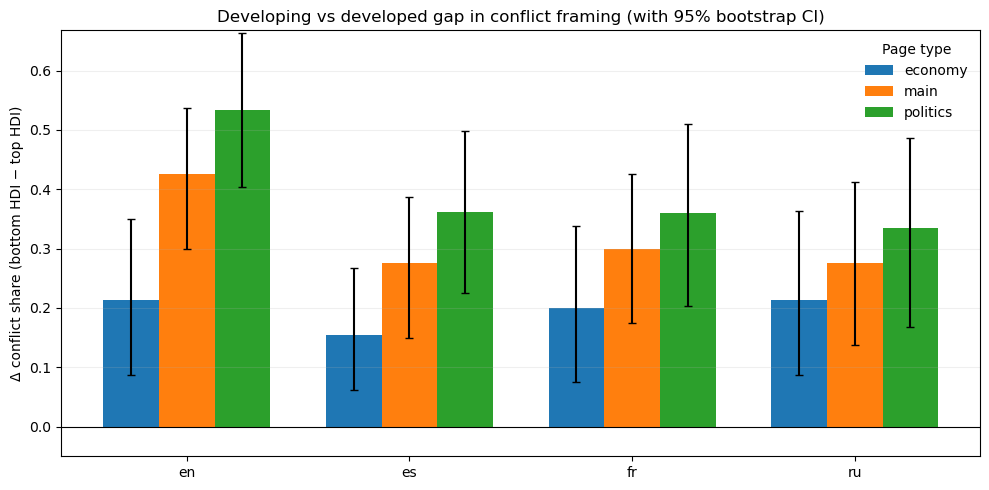

Saved: figs/main_result_gap_plot.png
HDI labels used: BOTTOM = bottom20_developing | TOP = top20_developed

Gap table (first 10 rows):
  lang requested_page_type  bottom_mean  bottom_n_countries  top_mean  \
0   en             economy     0.237500                  20  0.025000   
1   en                main     0.562500                  20  0.137500   
2   en            politics     0.614167                  20  0.080000   
3   es             economy     0.166667                  20  0.012500   
4   es                main     0.375000                  20  0.100000   
5   es            politics     0.370833                  20  0.010000   
6   fr             economy     0.287500                  20  0.087500   
7   fr                main     0.450000                  20  0.150000   
8   fr            politics     0.465833                  20  0.105833   
9   ru             economy     0.212500                  20  0.000000   

   top_n_countries     delta    ci_low   ci_high   err_low  e

In [ ]:
# Main-result plot: "Developed vs Developing gap" in conflict framing
# Produces a GAP plot: Δ = ConflictShare(bottom_HDI) - ConflictShare(top_HDI)
#
# Input expected: section-level labeled data (e.g., data/analysis_ready.csv)
# Required columns: lang, requested_page_type, hdi_group, frame
# Also needs a country identifier column (country/qid/etc.) for country-level bootstrap.

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Config
# -----------------------------
ANALYSIS_PATH = "data/analysis_ready.csv"
OUT_PATH = "figs/main_result_gap_plot.png"
B = 2000                 # bootstrap reps
ALPHA = 0.05             # 95% CI
INCLUDE_PAGE_TYPE = True # True = language × page_type bars; False = just language
SEED = 0

os.makedirs(os.path.dirname(OUT_PATH), exist_ok=True)

# -----------------------------
# Load
# -----------------------------
df = pd.read_csv(ANALYSIS_PATH)

required = {"lang", "hdi_group", "frame"}
if INCLUDE_PAGE_TYPE:
    required.add("requested_page_type")
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Find a country identifier column for bootstrap
country_col = None
for c in ["country", "country_name", "country_clean", "entity", "qid", "country_qid"]:
    if c in df.columns:
        country_col = c
        break
if country_col is None:
    raise ValueError(
        "Need a country identifier column for country-level bootstrap. "
        "Expected one of: country, country_name, country_clean, entity, qid, country_qid"
    )

# Keep only known frames
df = df[df["frame"].isin(["conflict", "development", "neutral"])].copy()

# -----------------------------
# Identify top/bottom HDI group labels in your data
# -----------------------------
# Your plot labels suggest these exact strings:
#   bottom20_developing, middle20, top20_developed
# If yours differ, adjust here.
BOTTOM_LABEL = None
TOP_LABEL = None

hdi_vals = sorted(df["hdi_group"].dropna().unique().tolist())
for v in hdi_vals:
    lv = str(v).lower()
    if "bottom" in lv and BOTTOM_LABEL is None:
        BOTTOM_LABEL = v
    if "top" in lv and TOP_LABEL is None:
        TOP_LABEL = v

if BOTTOM_LABEL is None or TOP_LABEL is None:
    raise ValueError(
        f"Couldn't infer top/bottom HDI group labels from: {hdi_vals}. "
        "Set BOTTOM_LABEL and TOP_LABEL manually."
    )

# -----------------------------
# Step 1: country-level conflict share within each cell
# -----------------------------
df["is_conflict"] = (df["frame"] == "conflict").astype(int)

group_cols = ["lang", "hdi_group", country_col]
if INCLUDE_PAGE_TYPE:
    group_cols.insert(1, "requested_page_type")

country_cell = (
    df.groupby(group_cols)
      .agg(n_sections=("frame", "size"),
           conflict_share=("is_conflict", "mean"))
      .reset_index()
)

# -----------------------------
# Step 2: cell means by HDI group (mean across countries)
# -----------------------------
mean_cols = ["lang", "hdi_group"]
if INCLUDE_PAGE_TYPE:
    mean_cols.insert(1, "requested_page_type")

cell_means = (
    country_cell.groupby(mean_cols)
      .agg(mean_conflict_share=("conflict_share", "mean"),
           n_countries=(country_col, "nunique"))
      .reset_index()
)

# -----------------------------
# Step 3: compute GAP: bottom - top
# -----------------------------
idx_cols = ["lang"]
if INCLUDE_PAGE_TYPE:
    idx_cols.insert(1, "requested_page_type")

bottom = cell_means[cell_means["hdi_group"] == BOTTOM_LABEL].set_index(idx_cols)
top = cell_means[cell_means["hdi_group"] == TOP_LABEL].set_index(idx_cols)

gap = bottom[["mean_conflict_share", "n_countries"]].rename(
    columns={"mean_conflict_share": "bottom_mean", "n_countries": "bottom_n_countries"}
).join(
    top[["mean_conflict_share", "n_countries"]].rename(
        columns={"mean_conflict_share": "top_mean", "n_countries": "top_n_countries"}
    ),
    how="inner",
)

gap["delta"] = gap["bottom_mean"] - gap["top_mean"]
gap = gap.reset_index()

# -----------------------------
# Step 4: Bootstrap CI on delta (resample COUNTRIES within each (lang, page_type, HDI))
# -----------------------------
rng = np.random.default_rng(SEED)

# Pre-split country_cell for efficient resampling
boot_cells = {}
for keys, sub in country_cell.groupby(idx_cols + ["hdi_group"]):
    # keys is a tuple: (lang, [page_type], hdi_group)
    countries = sub[country_col].dropna().unique()
    if len(countries) == 0:
        continue
    boot_cells[keys] = (sub, countries)

def bootstrap_delta(lang, page_type=None):
    draws = []
    for _ in range(B):
        if INCLUDE_PAGE_TYPE:
            bottom_rows = country_cell[(country_cell["lang"] == lang) &
                                       (country_cell["requested_page_type"] == page_type) &
                                       (country_cell["hdi_group"] == BOTTOM_LABEL)]
            top_rows = country_cell[(country_cell["lang"] == lang) &
                                    (country_cell["requested_page_type"] == page_type) &
                                    (country_cell["hdi_group"] == TOP_LABEL)]
        else:
            bottom_rows = country_cell[(country_cell["lang"] == lang) &
                                       (country_cell["hdi_group"] == BOTTOM_LABEL)]
            top_rows = country_cell[(country_cell["lang"] == lang) &
                                    (country_cell["hdi_group"] == TOP_LABEL)]

        if bottom_rows.empty or top_rows.empty:
            continue

        b_vals = bottom_rows["conflict_share"].to_numpy()
        t_vals = top_rows["conflict_share"].to_numpy()

        b_samp = rng.choice(b_vals, size=len(b_vals), replace=True)
        t_samp = rng.choice(t_vals, size=len(t_vals), replace=True)

        draws.append(float(b_samp.mean() - t_samp.mean()))
    return np.array(draws, dtype=float)


# Compute CIs for each bar
ci_rows = []
if INCLUDE_PAGE_TYPE:
    for (lang, pt) in gap[idx_cols].drop_duplicates().itertuples(index=False, name=None):
        draws = bootstrap_delta(lang, pt)
        if len(draws) < 50:
            ci_rows.append((lang, pt, np.nan, np.nan))
        else:
            lo = np.quantile(draws, ALPHA / 2)
            hi = np.quantile(draws, 1 - ALPHA / 2)
            ci_rows.append((lang, pt, lo, hi))
    ci = pd.DataFrame(ci_rows, columns=["lang", "requested_page_type", "ci_low", "ci_high"])
else:
    for lang in gap["lang"].drop_duplicates():
        draws = bootstrap_delta(lang)
        if len(draws) < 50:
            ci_rows.append((lang, np.nan, np.nan))
        else:
            lo = np.quantile(draws, ALPHA / 2)
            hi = np.quantile(draws, 1 - ALPHA / 2)
            ci_rows.append((lang, lo, hi))
    ci = pd.DataFrame(ci_rows, columns=["lang", "ci_low", "ci_high"])

gap = gap.merge(ci, on=idx_cols, how="left")
gap["err_low"] = gap["delta"] - gap["ci_low"]
gap["err_high"] = gap["ci_high"] - gap["delta"]



#------------------------------
# Write results into a file
#------------------------------
OUT_XLSX = "figs/main_result_conflict_gap_table.xlsx"
os.makedirs(os.path.dirname(OUT_XLSX), exist_ok=True)

# Pick a clean, audit-friendly column order
cols = []
if INCLUDE_PAGE_TYPE:
    cols += ["lang", "requested_page_type"]
cols += [
    "bottom_mean", "top_mean", "delta",
    "ci_low", "ci_high",
    "bottom_n_countries", "top_n_countries"
]

export_df = gap[cols].copy()

# Round up
export_df[["bottom_mean","top_mean","delta","ci_low","ci_high"]] = export_df[
    ["bottom_mean","top_mean","delta","ci_low","ci_high"]
].round(3)

# Write to Excel
export_df.to_excel(OUT_XLSX, index=False)

print("Saved Excel table:", OUT_XLSX)

# -----------------------------
# Plot
# -----------------------------
gap = gap.sort_values(["lang"] + (["requested_page_type"] if INCLUDE_PAGE_TYPE else []))

langs = sorted(gap["lang"].unique().tolist())
x = np.arange(len(langs))

fig, ax = plt.subplots(figsize=(10, 5))

ax.axhline(0, color="black", linewidth=0.8)

if INCLUDE_PAGE_TYPE:
    page_types = sorted(gap["requested_page_type"].unique().tolist())
    bar_w = 0.25 if len(page_types) <= 3 else 0.18
    offsets = (np.arange(len(page_types)) - (len(page_types) - 1) / 2) * bar_w

    for j, pt in enumerate(page_types):
        sub = gap[gap["requested_page_type"] == pt].set_index("lang").reindex(langs)

        y = sub["delta"].values
        lo = sub["ci_low"].values
        hi = sub["ci_high"].values

        yerr = None
        if not (np.all(np.isnan(lo)) or np.all(np.isnan(hi))):
            yerr = np.vstack([y - lo, hi - y])

        ax.bar(x + offsets[j], y, width=bar_w, label=pt, yerr=yerr, capsize=3)

    ax.legend(title="Page type", frameon=False)
else:
    sub = gap.set_index("lang").reindex(langs)
    y = sub["delta"].values
    lo = sub["ci_low"].values
    hi = sub["ci_high"].values

    yerr = None
    if not (np.all(np.isnan(lo)) or np.all(np.isnan(hi))):
        yerr = np.vstack([y - lo, hi - y])

    ax.bar(x, y, width=0.6, yerr=yerr, capsize=3)

ax.set_xticks(x)
ax.set_xticklabels(langs)
ax.set_ylabel("Δ conflict share (bottom HDI − top HDI)")
ax.set_title("Developing vs developed gap in conflict framing (with 95% bootstrap CI)")

# reasonable y-limits
ymax = np.nanmax(np.abs(gap["delta"].values))
ax.set_ylim(-0.05, max(0.05, ymax * 1.25))
ax.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.savefig(OUT_PATH, dpi=200)
plt.show()

print("Saved:", OUT_PATH)
print("HDI labels used:", "BOTTOM =", BOTTOM_LABEL, "| TOP =", TOP_LABEL)
print("\nGap table (first 10 rows):")
print(gap.head(10))


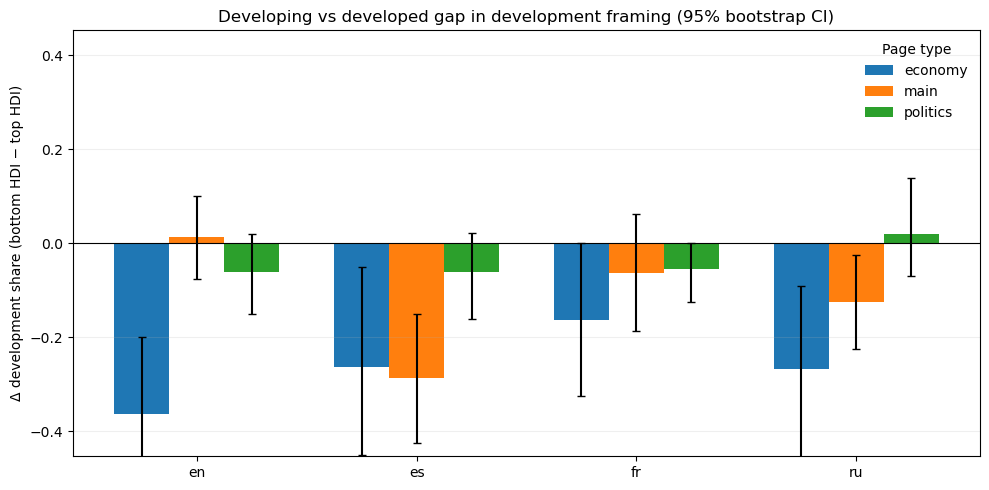

Saved: figs/dev_gap_plot.png
   lang requested_page_type  bottom_mean  bottom_n_countries  top_mean  \
0    en             economy     0.350000                  20  0.712500   
1    en                main     0.125000                  20  0.112500   
2    en            politics     0.030000                  20  0.090000   
3    es             economy     0.362500                  20  0.625000   
4    es                main     0.125000                  20  0.412500   
5    es            politics     0.042500                  20  0.103333   
6    fr             economy     0.462500                  20  0.625000   
7    fr                main     0.137500                  20  0.200000   
8    fr            politics     0.010000                  20  0.065000   
9    ru             economy     0.383333                  20  0.650000   
10   ru                main     0.100000                  20  0.225000   
11   ru            politics     0.080000                  20  0.060000   

    top_

In [6]:
# Development-gap plot: Δ_dev = DevShare(bottom_HDI) - DevShare(top_HDI)
# Same structure as your conflict gap plot, with 95% bootstrap CI.

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ANALYSIS_PATH = "data/analysis_ready.csv"
OUT_PATH = "figs/dev_gap_plot.png"
B = 2000
ALPHA = 0.05
INCLUDE_PAGE_TYPE = True
SEED = 0

BOTTOM_LABEL = "bottom20_developing"
TOP_LABEL = "top20_developed"

os.makedirs(os.path.dirname(OUT_PATH), exist_ok=True)

df = pd.read_csv(ANALYSIS_PATH)

required = {"lang", "hdi_group", "frame"}
if INCLUDE_PAGE_TYPE:
    required.add("requested_page_type")
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}")

country_col = None
for c in ["country", "country_name", "country_clean", "entity", "qid", "country_qid"]:
    if c in df.columns:
        country_col = c
        break
if country_col is None:
    raise ValueError("Need a country identifier column for bootstrap (country/qid/etc.).")

df = df[df["frame"].isin(["conflict", "development", "neutral"])].copy()

# ---- change here: development indicator ----
df["is_dev"] = (df["frame"] == "development").astype(int)

# country-level dev share within each (lang, page_type, hdi_group, country)
group_cols = ["lang", "hdi_group", country_col]
if INCLUDE_PAGE_TYPE:
    group_cols.insert(1, "requested_page_type")

country_cell = (
    df.groupby(group_cols)
      .agg(dev_share=("is_dev", "mean"))
      .reset_index()
)

# cell means by HDI group (mean across countries)
mean_cols = ["lang", "hdi_group"]
if INCLUDE_PAGE_TYPE:
    mean_cols.insert(1, "requested_page_type")

cell_means = (
    country_cell.groupby(mean_cols)
      .agg(mean_dev_share=("dev_share", "mean"),
           n_countries=(country_col, "nunique"))
      .reset_index()
)

idx_cols = ["lang"]
if INCLUDE_PAGE_TYPE:
    idx_cols.insert(1, "requested_page_type")

bottom = cell_means[cell_means["hdi_group"] == BOTTOM_LABEL].set_index(idx_cols)
top = cell_means[cell_means["hdi_group"] == TOP_LABEL].set_index(idx_cols)

gap = bottom[["mean_dev_share", "n_countries"]].rename(
    columns={"mean_dev_share": "bottom_mean", "n_countries": "bottom_n_countries"}
).join(
    top[["mean_dev_share", "n_countries"]].rename(
        columns={"mean_dev_share": "top_mean", "n_countries": "top_n_countries"}
    ),
    how="inner",
)
gap["delta"] = gap["bottom_mean"] - gap["top_mean"]
gap = gap.reset_index()

# bootstrap on country-level dev shares (preserves multiplicity)
rng = np.random.default_rng(SEED)

def bootstrap_delta(lang, page_type=None):
    draws = []
    for _ in range(B):
        if INCLUDE_PAGE_TYPE:
            b = country_cell[(country_cell["lang"] == lang) &
                             (country_cell["requested_page_type"] == page_type) &
                             (country_cell["hdi_group"] == BOTTOM_LABEL)]
            t = country_cell[(country_cell["lang"] == lang) &
                             (country_cell["requested_page_type"] == page_type) &
                             (country_cell["hdi_group"] == TOP_LABEL)]
        else:
            b = country_cell[(country_cell["lang"] == lang) & (country_cell["hdi_group"] == BOTTOM_LABEL)]
            t = country_cell[(country_cell["lang"] == lang) & (country_cell["hdi_group"] == TOP_LABEL)]

        if b.empty or t.empty:
            continue

        b_vals = b["dev_share"].to_numpy()
        t_vals = t["dev_share"].to_numpy()

        draws.append(float(rng.choice(b_vals, size=len(b_vals), replace=True).mean()
                          - rng.choice(t_vals, size=len(t_vals), replace=True).mean()))
    return np.array(draws, dtype=float)

ci_rows = []
if INCLUDE_PAGE_TYPE:
    for (lang, pt) in gap[idx_cols].drop_duplicates().itertuples(index=False, name=None):
        draws = bootstrap_delta(lang, pt)
        if len(draws) < 50:
            ci_rows.append((lang, pt, np.nan, np.nan))
        else:
            lo = np.quantile(draws, ALPHA/2)
            hi = np.quantile(draws, 1-ALPHA/2)
            ci_rows.append((lang, pt, lo, hi))
    ci = pd.DataFrame(ci_rows, columns=["lang", "requested_page_type", "ci_low", "ci_high"])
else:
    for lang in gap["lang"].drop_duplicates():
        draws = bootstrap_delta(lang)
        if len(draws) < 50:
            ci_rows.append((lang, np.nan, np.nan))
        else:
            lo = np.quantile(draws, ALPHA/2)
            hi = np.quantile(draws, 1-ALPHA/2)
            ci_rows.append((lang, lo, hi))
    ci = pd.DataFrame(ci_rows, columns=["lang", "ci_low", "ci_high"])

gap = gap.merge(ci, on=idx_cols, how="left")

# ---- Plot ----
langs = sorted(gap["lang"].unique().tolist())
x = np.arange(len(langs))

fig, ax = plt.subplots(figsize=(10, 5))
ax.axhline(0, color="black", linewidth=0.8)

if INCLUDE_PAGE_TYPE:
    page_types = sorted(gap["requested_page_type"].unique().tolist())
    bar_w = 0.25 if len(page_types) <= 3 else 0.18
    offsets = (np.arange(len(page_types)) - (len(page_types)-1)/2) * bar_w

    for j, pt in enumerate(page_types):
        sub = gap[gap["requested_page_type"] == pt].set_index("lang").reindex(langs)
        y = sub["delta"].values
        lo = sub["ci_low"].values
        hi = sub["ci_high"].values
        yerr = None
        if not (np.all(np.isnan(lo)) or np.all(np.isnan(hi))):
            yerr = np.vstack([y - lo, hi - y])
        ax.bar(x + offsets[j], y, width=bar_w, label=pt, yerr=yerr, capsize=3)

    ax.legend(title="Page type", frameon=False)
else:
    sub = gap.set_index("lang").reindex(langs)
    y = sub["delta"].values
    lo = sub["ci_low"].values
    hi = sub["ci_high"].values
    yerr = None
    if not (np.all(np.isnan(lo)) or np.all(np.isnan(hi))):
        yerr = np.vstack([y - lo, hi - y])
    ax.bar(x, y, width=0.6, yerr=yerr, capsize=3)

ax.set_xticks(x)
ax.set_xticklabels(langs)
ax.set_ylabel("Δ development share (bottom HDI − top HDI)")
ax.set_title("Developing vs developed gap in development framing (95% bootstrap CI)")
ax.grid(axis="y", alpha=0.2)

ymax = np.nanmax(np.abs(gap["delta"].values))
ax.set_ylim(-max(0.05, ymax*1.25), max(0.05, ymax*1.25))

plt.tight_layout()
plt.savefig(OUT_PATH, dpi=200)
plt.show()

print("Saved:", OUT_PATH)
print(gap.head(12))


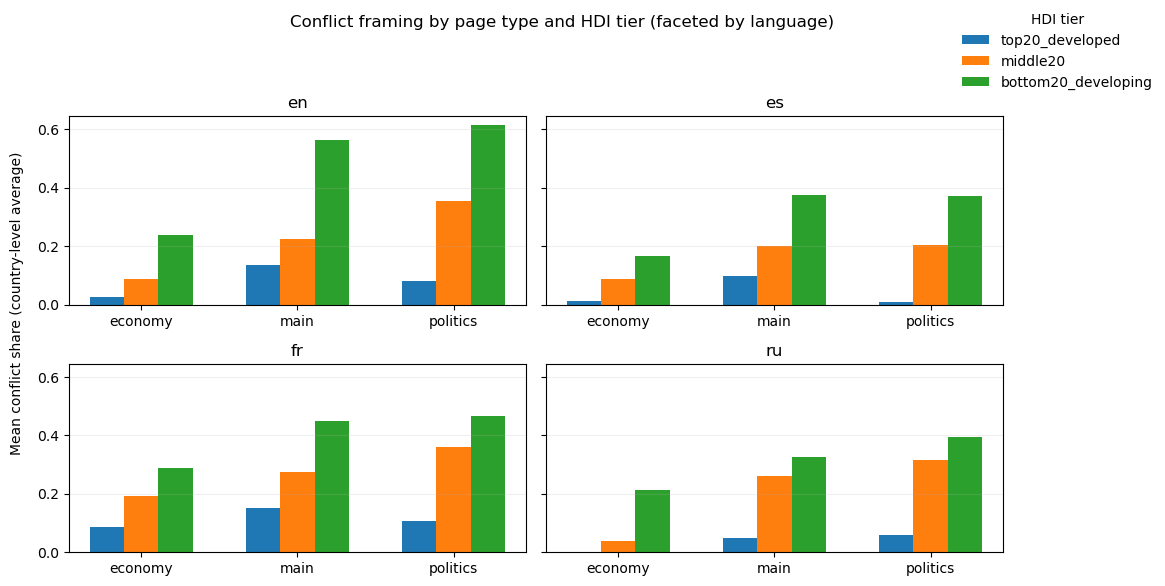

Saved: figs/slide3_conflict_by_pagetype_hdi_faceted_by_language.png


In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ANALYSIS_PATH = "data/analysis_ready.csv"
OUT_PATH = "figs/slide3_conflict_by_pagetype_hdi_faceted_by_language.png"

os.makedirs(os.path.dirname(OUT_PATH), exist_ok=True)

df = pd.read_csv(ANALYSIS_PATH)

required = {"lang", "requested_page_type", "hdi_group", "frame"}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# pick a country id column (country-level averaging)
country_col = None
for c in ["country", "country_name", "country_clean", "entity", "qid", "country_qid"]:
    if c in df.columns:
        country_col = c
        break
if country_col is None:
    raise ValueError("Need a country identifier column (country/qid/etc.)")

df = df[df["frame"].isin(["conflict", "development", "neutral"])].copy()
df["is_conflict"] = (df["frame"] == "conflict").astype(int)

# Country-level conflict share per (lang, page_type, hdi, country)
country_cell = (
    df.groupby(["lang", "requested_page_type", "hdi_group", country_col])
      .agg(conflict_share=("is_conflict", "mean"))
      .reset_index()
)

# Mean across countries (each country equal weight)
means = (
    country_cell.groupby(["lang", "requested_page_type", "hdi_group"])
      .agg(mean_conflict_share=("conflict_share", "mean"),
           n_countries=(country_col, "nunique"))
      .reset_index()
)

# Orderings (adjust if your hdi_group strings differ)
hdi_order = ["top20_developed", "middle20", "bottom20_developing"]
# keep only those present and in order
hdi_order = [h for h in hdi_order if h in means["hdi_group"].unique()]

lang_order = ["en", "es", "fr", "ru"]
lang_order = [l for l in lang_order if l in means["lang"].unique()]

pt_order = ["economy", "main", "politics"]
pt_order = [p for p in pt_order if p in means["requested_page_type"].unique()]

# Prepare faceted plot: 2x2 for four languages
n_lang = len(lang_order)
nrows = 2 if n_lang > 2 else 1
ncols = 2 if n_lang > 1 else 1

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 6), sharey=True)
axes = np.array(axes).reshape(nrows, ncols)

bar_w = 0.22 if len(hdi_order) == 3 else 0.28
x = np.arange(len(pt_order))
offsets = (np.arange(len(hdi_order)) - (len(hdi_order) - 1) / 2) * bar_w

for i, lang in enumerate(lang_order):
    ax = axes[i // ncols, i % ncols]
    sub_lang = means[means["lang"] == lang]

    for j, hdi in enumerate(hdi_order):
        sub = (sub_lang[sub_lang["hdi_group"] == hdi]
               .set_index("requested_page_type")
               .reindex(pt_order))

        y = sub["mean_conflict_share"].values
        ax.bar(x + offsets[j], y, width=bar_w, label=hdi)

    ax.set_title(f"{lang}")
    ax.set_xticks(x)
    ax.set_xticklabels(pt_order)
    ax.grid(axis="y", alpha=0.2)

# Hide unused axes (if any)
for k in range(n_lang, nrows * ncols):
    axes[k // ncols, k % ncols].axis("off")

# Shared labels + legend
fig.suptitle("Conflict framing by page type and HDI tier (faceted by language)")
fig.text(0.04, 0.5, "Mean conflict share (country-level average)", va="center", rotation="vertical")
handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, title="HDI tier", loc="upper right", frameon=False)

plt.tight_layout(rect=[0.05, 0.02, 0.88, 0.92])
plt.savefig(OUT_PATH, dpi=200)
plt.show()

print("Saved:", OUT_PATH)


##Specification check

In [ ]:
import os
import numpy as np
import pandas as pd

ANALYSIS_PATH = "data/analysis_ready.csv"
OUT_DIR = "figs"
os.makedirs(OUT_DIR, exist_ok=True)

B = 2000
ALPHA = 0.05
SEED = 0
rng = np.random.default_rng(SEED)

df0 = pd.read_csv(ANALYSIS_PATH)

# --- Identify a country id column (same logic as your current cell) ---
country_col = None
for c in ["country", "country_name", "country_clean", "entity", "qid", "country_qid"]:
    if c in df0.columns:
        country_col = c
        break
if country_col is None:
    raise ValueError("No country identifier column found for country-level bootstrap.")

# --- Helpers ---
def country_level_share(df, frame_name, group_cols):
    """
    Compute per-country share of `frame_name` within each group (lang x page_type x hdi_group).
    """
    d = df.copy()
    d["is_target"] = (d["frame"] == frame_name).astype(int)

    # country-group totals
    g = d.groupby(group_cols + [country_col], as_index=False).agg(
        n=("frame", "count"),
        n_target=("is_target", "sum"),
    )
    g["share"] = g["n_target"] / g["n"]
    return g

def bootstrap_gap(country_shares, group_cols, bottom_label, top_label):
    """
    For each (lang, page_type), bootstrap over countries to get:
    gap = mean(bottom) - mean(top)
    """
    out_rows = []

    # iterate by (lang, requested_page_type)
    for keys, sub in country_shares.groupby(group_cols, dropna=False):
        # keys is tuple if multiple cols, else scalar
        keys = keys if isinstance(keys, tuple) else (keys,)
        key_dict = dict(zip(group_cols, keys))

        bottom = sub[sub["hdi_group"] == bottom_label]["share"].to_numpy()
        top = sub[sub["hdi_group"] == top_label]["share"].to_numpy()

        # must have at least 2 countries in each group to bootstrap sanely
        if len(bottom) < 2 or len(top) < 2:
            continue

        gaps = np.empty(B, dtype=float)
        for b in range(B):
            bb = rng.choice(bottom, size=len(bottom), replace=True).mean()
            tt = rng.choice(top, size=len(top), replace=True).mean()
            gaps[b] = bb - tt

        gap_hat = gaps.mean()
        lo = np.quantile(gaps, ALPHA / 2)
        hi = np.quantile(gaps, 1 - ALPHA / 2)

        out_rows.append({**key_dict, "gap": gap_hat, "ci_lo": lo, "ci_hi": hi,
                         "n_bottom": len(bottom), "n_top": len(top)})
    return pd.DataFrame(out_rows)

def run_variant(name, df):
    # infer bottom/top HDI labels the same way you already do
    hdi_vals = sorted(df["hdi_group"].dropna().unique().tolist())
    bottom_label = next((v for v in hdi_vals if "bottom" in str(v).lower()), None)
    top_label = next((v for v in hdi_vals if "top" in str(v).lower()), None)
    if bottom_label is None or top_label is None:
        raise ValueError(f"Could not infer top/bottom HDI labels from: {hdi_vals}")

    group_cols = ["lang", "requested_page_type"]
    shares = country_level_share(df, frame_name="conflict", group_cols=group_cols + ["hdi_group"])
    res = bootstrap_gap(shares, group_cols=group_cols, bottom_label=bottom_label, top_label=top_label)
    res["variant"] = name
    return res

# --- Variant filters ---
df_all = df0.copy()

df_lead = df0[df0["heading"].astype(str) == "__LEAD__"].copy()
df_nonlead = df0[df0["heading"].astype(str) != "__LEAD__"].copy()

# fallback exclusion: economy/politics sourced from main
if "source_page_type" in df0.columns:
    df_no_fallback = df0[~(
        df0["requested_page_type"].isin(["economy", "politics"]) &
        (df0["source_page_type"] == "main")
    )].copy()
else:
    df_no_fallback = df0.copy()  # if column absent, skip

# --- Run and export a single robustness table ---
res = pd.concat([
    run_variant("all_sections", df_all),
    run_variant("lead_only", df_lead),
    run_variant("nonlead_only", df_nonlead),
    run_variant("exclude_main_fallback", df_no_fallback),
], ignore_index=True)

out_csv = "data/robustness_conflict_gaps.csv"
res.to_csv(out_csv, index=False)
print("Saved:", out_csv)

display(res.sort_values(["variant", "gap"], ascending=[True, False]).head(20))